# ML Model Comparison — CV Structural Parsing Layer
## Kilani Groupe — PFE Experimentation Report

**Objective:** Compare three classification architectures for structural block detection
in a CV line (Section Header, Job Title, Company, Bullet Point, Diploma, Contact, Other).

**Models tested:**
1. `Random Forest` — robust baseline, interpretable
2. `LightGBM` — optimised gradient boosting
3. `Voting Ensemble` RF + ExtraTrees + GBM — production model

**Metrics:** Accuracy, F1-weighted, per-class F1, Confusion Matrix, Learning Curve

---

**Notebook structure:**
1. Installation & Imports
2. Constants & Feature Engineering
3. Dataset Loading
4. Training Dataset Construction
5. Model Definition & Training
6. Metric Summary Table
7. Comparative Charts
8. Confusion Matrices
9. Learning Curves
10. Final Summary Dashboard
11. Detailed Classification Reports
12. Multi-Criteria Analysis & Final Decision
13. Summary (for report)
14. Export & Download


---
## 1. Installation & Imports


In [1]:
# Install dependencies
!pip install -q lightgbm scikit-learn pandas numpy matplotlib seaborn kagglehub tqdm


In [2]:
import os, re, json, hashlib, warnings, time
import unicodedata
from pathlib import Path
from collections import Counter
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm import tqdm

from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier, VotingClassifier
)
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, learning_curve
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)
from lightgbm import LGBMClassifier
import kagglehub

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})

print('Imports OK')


Imports OK


---
## 2. Constants & Feature Engineering
*Reproduced from `cv_extractor.py` — identical to production*


In [3]:
# Block class definitions
BLOCK_TYPES = {
    'SECTION_HEADER': 0, 'JOB_TITLE': 1, 'COMPANY': 2,
    'BULLET_POINT':   3, 'DIPLOMA':   4, 'CONTACT': 5, 'OTHER': 6,
}
BLOCK_NAMES  = {v: k for k, v in BLOCK_TYPES.items()}
N_CLASSES    = len(BLOCK_TYPES)
CLASS_LABELS = [BLOCK_NAMES[i] for i in range(N_CLASSES)]

BLOCK_COLORS = {
    'SECTION_HEADER': '#2196F3', 'JOB_TITLE': '#4CAF50',
    'COMPANY':        '#FF9800', 'BULLET_POINT': '#9C27B0',
    'DIPLOMA':        '#F44336', 'CONTACT': '#00BCD4', 'OTHER': '#9E9E9E',
}

_EMAIL_RE = re.compile(
    r"[a-zA-Z0-9._%+\-]+@[a-zA-Z0-9.\-]+\.[a-zA-Z]{2,}"
)
_DATE_RANGE_RE = re.compile(
    r'((?:19|20)\d{2})\s*[-\u2013\u2014/]\s*'
    r"((?:19|20)\d{2}|pr[eé]sent|actuel|current|now|ongoing)",
    re.IGNORECASE
)

SECTION_ANCHORS_FLAT = {
    'experience','experiences','education','formation','formations',
    'competences','skills','langues','languages','certifications',
    'profil','summary','profile','projets','projects','stage','stages',
    'diplomes','degrees','contact','about','associations','parcours',
    'work experience','professional experience','technical skills',
}

DIPLOMA_PATTERNS = [
    r"Ing[eé]nieur\s+(?:en\s+)?[\w\s\-']{2,50}",
    r"Licence\s+(?:en|de|Professionnelle)[\w\s\-']{0,40}",
    r"Master\s+(?:en|de|of|Professionnel)[\w\s\-']{0,40}",
    r"Bachelor\s+(?:of|in)\s+[\w\s\-']{2,40}",
    r"(?:MSc|MBA|PhD|BSc)\s+[\w\s\(\)\-']{2,40}",
    r"Doctorat\s+en\s+[\w\s\-']{2,40}",
]

COMPANY_PATTERNS = [
    r'\b(?:s\.?a\.?r\.?l\.?|s\.?a\.?s\.?|s\.?a\.?)\b',
    r'\b(?:group(?:e)?|holding|corp|inc\.?|ltd\.?)\b',
    r'\b(?:telecom|technologies?|solutions?|consulting|services?)\b',
]

print(f'Constants OK — {N_CLASSES} classes: {CLASS_LABELS}')


Constants OK — 7 classes: ['SECTION_HEADER', 'JOB_TITLE', 'COMPANY', 'BULLET_POINT', 'DIPLOMA', 'CONTACT', 'OTHER']


In [4]:
def extract_structural_features(
    line: str, prev_line: str = '', next_line: str = '',
    position: int = 0, total_lines: int = 1,
) -> dict:
    lc    = line.strip()
    words = lc.split()
    alpha = [c for c in lc if c.isalpha()]
    upper_ratio = sum(1 for c in alpha if c.isupper()) / max(len(alpha), 1)
    digit_ratio = sum(1 for c in lc if c.isdigit()) / max(len(lc), 1)
    special     = sum(1 for c in lc if c in '@.:;/\\|+()[]{}#%&')
    char_var    = len(set(lc.lower())) / max(len(lc), 1)
    return {
        'length':           min(len(lc), 300),
        'word_count':       len(words),
        'avg_word_len':     round(np.mean([len(w) for w in words]) if words else 0, 2),
        'position_ratio':   round(position / max(total_lines, 1), 3),
        'is_first_5':       int(position < 5),
        'is_first_15':      int(position < 15),
        'is_top_20pct':     int(position < total_lines * 0.20),
        'is_bottom_20pct':  int(position > total_lines * 0.80),
        'is_all_upper':     int(bool(lc) and lc.isupper()),
        'is_title_case':    int(bool(lc) and lc.istitle()),
        'is_all_lower':     int(bool(lc) and lc.islower()),
        'upper_ratio':      round(upper_ratio, 2),
        'starts_upper':     int(bool(lc) and lc[0].isupper()),
        'is_short':         int(len(lc) < 20),
        'is_medium':        int(20 <= len(lc) < 60),
        'is_long':          int(len(lc) >= 60),
        'is_very_long':     int(len(lc) >= 120),
        'has_colon':        int(':' in lc),
        'has_pipe':         int('|' in lc),
        'has_slash':        int('/' in lc),
        'has_dash':         int('-' in lc or '\u2013' in lc),
        'has_comma':        int(',' in lc),
        'has_dot':          int('.' in lc),
        'has_parentheses':  int('(' in lc and ')' in lc),
        'has_at_sign':      int('@' in lc),
        'has_plus':         int('+' in lc),
        'special_char_count': min(special, 10),
        'is_bullet_start':  int(lc[:1] in '\u2022-*\u25aa\u25b8\xb7\u2013'
                                 or bool(re.match(r'^\d+[.)]\s', lc))),
        'bullet_char':      int(lc[:1] in '\u2022\u25aa\u25b8\xb7'),
        'has_digit':        int(any(c.isdigit() for c in lc)),
        'digit_ratio':      round(digit_ratio, 2),
        'has_4digit_seq':   int(bool(re.search(r'\d{4}', lc))),
        'has_date_sep':     int(bool(_DATE_RANGE_RE.search(lc))),
        'pure_number':      int(bool(re.match(r'^\d+$', lc))),
        'is_separator':     int(bool(re.match(r'^[-_=*\\.]{3,}$', lc))),
        'is_empty_ish':     int(len(lc) <= 2),
        'prev_empty':       int(len(prev_line.strip()) == 0),
        'prev_length':      min(len(prev_line.strip()), 200),
        'prev_is_upper':    int(bool(prev_line.strip()) and prev_line.strip().isupper()),
        'next_empty':       int(len(next_line.strip()) == 0),
        'next_length':      min(len(next_line.strip()), 200),
        'next_is_bullet':   int(next_line.strip()[:1] in '\u2022-*\u25aa\u25b8\xb7'),
        'surrounded_empty': int(not prev_line.strip() and not next_line.strip()),
        'contains_at':      int('@' in lc),
        'contains_www':     int('www' in lc.lower() or 'http' in lc.lower()),
        'word_count_small': int(1 <= len(words) <= 4),
        'is_md_h1':         int(lc.startswith('# ') and not lc.startswith('## ')),
        'is_md_h2':         int(lc.startswith('## ') and not lc.startswith('### ')),
        'is_md_h3':         int(lc.startswith('### ')),
        'is_md_bullet':     int(lc.startswith('- ') or lc.startswith('* ')),
        'is_md_hr':         int(lc == '---' or lc == '==='),
        'has_url':          int(bool(re.search(r'https?://|www\.', lc, re.I))),
        'starts_verb':      int(bool(re.match(r'^(?:develop|manag|design|implem|lead|build|creat|analys)', lc, re.I))),
        'has_semicolon':    int(';' in lc),
        'ends_colon':       int(lc.endswith(':')),
        'is_email_like':    int(bool(_EMAIL_RE.search(lc))),
        'is_phone_like':    int(bool(re.search(r'\+?\d[\d\s\-\.]{7,}', lc))),
        'char_variety':     round(char_var, 3),
    }

FEATURE_NAMES = list(extract_structural_features('test').keys())
print(f'Feature Engineering OK — {len(FEATURE_NAMES)} features')


Feature Engineering OK — 58 features


In [5]:
def annotate_line(line: str, prev: str, nxt: str) -> int:
    lc = line.strip()
    ll = lc.lower()
    if not lc or len(lc) < 2:                    return BLOCK_TYPES['OTHER']
    if re.match(r'^#{1,3}\s+', lc):              return BLOCK_TYPES['SECTION_HEADER']
    if re.match(r'^[-*]\s+\w', lc):              return BLOCK_TYPES['BULLET_POINT']
    if _EMAIL_RE.search(lc):                      return BLOCK_TYPES['CONTACT']
    if re.match(r'^\+?\d[\d\s.\-()]{8,}$', lc): return BLOCK_TYPES['CONTACT']
    if re.match(r'^[-_=*\.]{3,}$', lc):          return BLOCK_TYPES['OTHER']
    ll_clean = ll.strip(':').strip()
    if ll_clean in SECTION_ANCHORS_FLAT or any(ll_clean.startswith(a) for a in SECTION_ANCHORS_FLAT if len(a) > 5):
        return BLOCK_TYPES['SECTION_HEADER']
    for pat in DIPLOMA_PATTERNS:
        if re.search(pat, lc, re.I): return BLOCK_TYPES['DIPLOMA']
    if lc[:1] in '\u2022\u25aa\u25b8\xb7' or re.match(r'^\d+[.)]\s+\w', lc):
        return BLOCK_TYPES['BULLET_POINT']
    if any(re.search(p, ll, re.I) for p in COMPANY_PATTERNS) and len(lc) < 70:
        return BLOCK_TYPES['COMPANY']
    words = lc.split()
    if 2 <= len(words) <= 5 and not re.search(r'[\d@|]', lc) and lc[0].isupper():
        return BLOCK_TYPES['JOB_TITLE']
    return BLOCK_TYPES['OTHER']

print('Heuristic annotator OK')


Heuristic annotator OK


---
## 3. Dataset Loading


In [6]:
def load_resume_dataset_kaggle() -> pd.DataFrame:
    print('Downloading CV dataset...')
    try:
        path = kagglehub.dataset_download('snehaanbhawal/resume-dataset')
        frames = []
        for root, _, fnames in os.walk(path):
            for fname in fnames:
                if fname.endswith('.csv'):
                    try:
                        df_raw = pd.read_csv(os.path.join(root, fname), on_bad_lines='skip')
                        if 'Resume_str' in df_raw.columns:
                            frames.append(df_raw[['Resume_str']])
                            print(f'  {fname}: {len(df_raw):,} rows')
                    except Exception as e:
                        print(f'  {fname}: {e}')
        if frames:
            df = pd.concat(frames, ignore_index=True)
            df = df[df['Resume_str'].str.len() > 100].drop_duplicates().reset_index(drop=True)
            print(f'Dataset: {len(df):,} unique CVs')
            return df
    except Exception as e:
        print(f'Kaggle error: {e} — generating synthetic data')
    return pd.DataFrame()

RESUME_DF = load_resume_dataset_kaggle()


100%|██████████| 62.5M/62.5M [00:00<00:00, 103MB/s]

Extracting files...


  Resume.csv: 2,484 rows
Dataset: 2,481 unique CVs


In [7]:
def generate_synthetic_cv_data(n_cvs: int = 800) -> pd.DataFrame:
    section_headers = [
        'EXPERIENCE PROFESSIONNELLE', 'FORMATION', 'COMPETENCES',
        'LANGUES', 'CERTIFICATIONS', 'STAGES', 'PROJETS',
        'Work Experience', 'Education', 'Skills', 'Languages',
    ]
    job_titles = [
        'Developpeur Full Stack', 'Ingenieur Logiciel Senior',
        'Data Scientist', 'Chef de Projet IT', 'Analyste Developpeur',
        'Software Engineer', 'Backend Developer', 'DevOps Engineer',
    ]
    companies = [
        'Vermeg S.A', 'Telnet Holding', 'Sofrecom Tunisie',
        'Capgemini SARL', 'Orange Tunisie SA', 'Talan Group',
    ]
    diplomas = [
        "Diplome d'Ingenieur en Informatique",
        "Master en Intelligence Artificielle",
        "Licence en Genie Logiciel",
        "Master of Science in Computer Science",
    ]
    bullets = [
        '- REST API development with Spring Boot',
        '- CI/CD pipeline setup with Jenkins',
        '- SQL query optimisation, 40% performance gain',
        '- Microservices design with Docker/Kubernetes',
        '- React.js frontend with TypeScript',
    ]
    contacts = ['ahmed.benali@gmail.com', '+216 99 123 456', 'sana.triki@outlook.fr']
    cvs = []
    rng = np.random.default_rng(42)
    for _ in range(n_cvs):
        parts = list(rng.choice(contacts, size=rng.integers(1,3), replace=False))
        parts.append('')
        for sh in rng.choice(section_headers, size=rng.integers(3, 6), replace=False):
            parts.append(sh)
            for jt in rng.choice(job_titles, size=rng.integers(1, 3), replace=False):
                parts.append(jt)
            for co in rng.choice(companies, size=rng.integers(1, 2), replace=False):
                parts.append(co)
            parts.append(f"{rng.integers(2018,2023)} - {rng.integers(2023,2025)}")
            for b in rng.choice(bullets, size=rng.integers(2, 4), replace=False):
                parts.append(b)
            for dp in rng.choice(diplomas, size=rng.integers(1, 2), replace=False):
                parts.append(dp)
            parts.append('')
        cvs.append({'Resume_str': '\n'.join(str(p) for p in parts)})
    print(f'  {n_cvs} synthetic CVs generated')
    return pd.DataFrame(cvs)

if len(RESUME_DF) == 0:
    RESUME_DF = generate_synthetic_cv_data(800)

print(f'Final dataset: {len(RESUME_DF):,} CVs')


Final dataset: 2,481 CVs


---
## 4. Training Dataset Construction


In [8]:
from typing import Tuple

def build_training_dataset(df: pd.DataFrame, max_cvs: int = 2000) -> Tuple[np.ndarray, np.ndarray]:
    text_col = next((c for c in ['Resume_str', 'Resume', 'text'] if c in df.columns), None)
    if not text_col: return np.array([]), np.array([])
    all_X, all_y = [], []
    df_sample = df.sample(min(max_cvs, len(df)), random_state=42)
    for _, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc='Feature extraction'):
        lines = str(row[text_col]).split('\n')
        total = len(lines)
        for i, line in enumerate(lines):
            ls = line.strip()
            if not ls or len(ls) < 2: continue
            prev  = lines[i-1].strip() if i > 0 else ''
            nxt   = lines[i+1].strip() if i < total-1 else ''
            feats = extract_structural_features(ls, prev, nxt, i, total)
            label = annotate_line(ls, prev, nxt)
            all_X.append(list(feats.values()))
            all_y.append(label)
    return np.array(all_X), np.array(all_y)

def balance_classes(X, y, target_ratio=0.25):
    counts = Counter(y)
    majority_count = max(counts.values())
    X_parts, y_parts = [X], [y]
    rng = np.random.default_rng(42)
    for cls, cnt in counts.items():
        ratio  = 0.50 if cls == BLOCK_TYPES['DIPLOMA'] else target_ratio
        target = max(int(majority_count * ratio), cnt * 3)
        if cnt < target:
            idx   = np.where(y == cls)[0]
            extra = rng.choice(idx, size=target - cnt, replace=True)
            X_parts.append(X[extra])
            y_parts.append(np.full(target - cnt, cls))
    X_bal = np.vstack(X_parts)
    y_bal = np.concatenate(y_parts)
    perm  = rng.permutation(len(X_bal))
    return X_bal[perm], y_bal[perm]

print('Building training dataset...')
X_raw, y_raw = build_training_dataset(RESUME_DF, max_cvs=2000)
print(f'  Raw rows: {len(X_raw):,}')

dist = Counter(y_raw)
print('\n  Class distribution (raw):')
for cid, cnt in sorted(dist.items()):
    print(f'    {BLOCK_NAMES[cid]:<18}: {cnt:>6,} ({cnt/len(y_raw)*100:.1f}%)')

X_bal, y_bal = balance_classes(X_raw, y_raw)
print(f'\n  Balanced rows: {len(X_bal):,}')


Building training dataset...


Feature extraction: 100%|██████████| 2000/2000 [00:24<00:00, 81.64it/s] 


  Raw rows: 11,913

  Class distribution (raw):
    SECTION_HEADER    :    151 (1.3%)
    JOB_TITLE         :    727 (6.1%)
    COMPANY           :    116 (1.0%)
    BULLET_POINT      :    375 (3.1%)
    DIPLOMA           :  1,014 (8.5%)
    CONTACT           :     20 (0.2%)
    OTHER             :  9,510 (79.8%)

  Balanced rows: 45,170


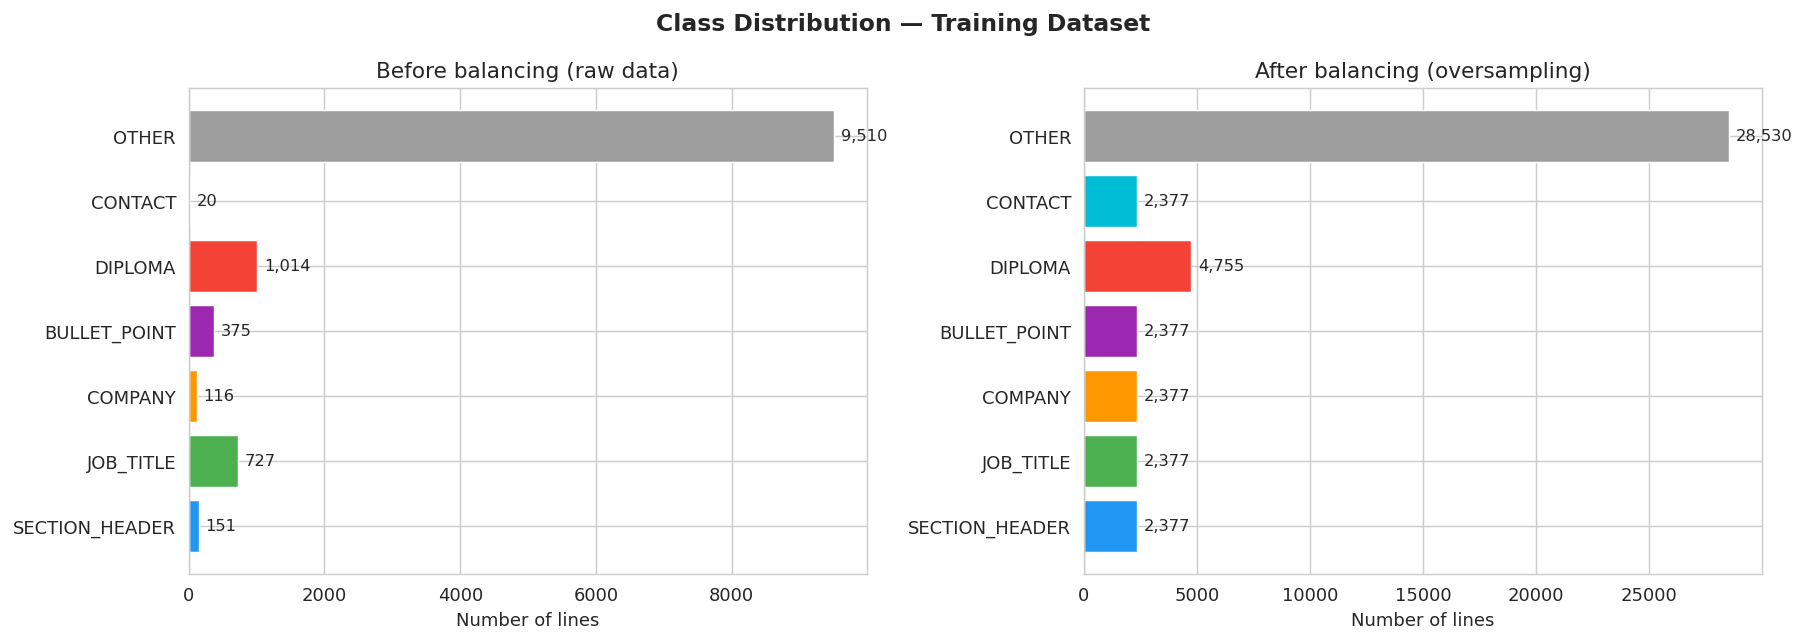

In [9]:
# Class distribution visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Distribution — Training Dataset', fontsize=13, fontweight='bold')

ax = axes[0]
labels_raw = [BLOCK_NAMES[i] for i in sorted(dist.keys())]
counts_raw = [dist[i] for i in sorted(dist.keys())]
colors_raw = [BLOCK_COLORS[l] for l in labels_raw]
bars = ax.barh(labels_raw, counts_raw, color=colors_raw, edgecolor='white', linewidth=0.8)
for bar, cnt in zip(bars, counts_raw):
    ax.text(bar.get_width() + max(counts_raw)*0.01, bar.get_y() + bar.get_height()/2,
            f'{cnt:,}', va='center', fontsize=9)
ax.set_title('Before balancing (raw data)')
ax.set_xlabel('Number of lines')

ax = axes[1]
dist_bal = Counter(y_bal)
labels_bal = [BLOCK_NAMES[i] for i in sorted(dist_bal.keys())]
counts_bal = [dist_bal[i] for i in sorted(dist_bal.keys())]
colors_bal = [BLOCK_COLORS[l] for l in labels_bal]
bars = ax.barh(labels_bal, counts_bal, color=colors_bal, edgecolor='white', linewidth=0.8)
for bar, cnt in zip(bars, counts_bal):
    ax.text(bar.get_width() + max(counts_bal)*0.01, bar.get_y() + bar.get_height()/2,
            f'{cnt:,}', va='center', fontsize=9)
ax.set_title('After balancing (oversampling)')
ax.set_xlabel('Number of lines')

plt.tight_layout()
plt.savefig('fig1_class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()


In [10]:
X_df = pd.DataFrame(X_bal, columns=FEATURE_NAMES)
X_train, X_test, y_train, y_test = train_test_split(
    X_df, y_bal, test_size=0.20, random_state=42, stratify=y_bal
)
print(f'Split: Train={len(X_train):,} | Test={len(X_test):,}')
print(f'Test class distribution: {Counter(y_test)}')


Split: Train=36,136 | Test=9,034
Test class distribution: Counter({np.int64(6): 5706, np.int64(4): 951, np.int64(3): 476, np.int64(0): 476, np.int64(5): 475, np.int64(2): 475, np.int64(1): 475})


---
## 5. Model Definition & Training


In [11]:
MODELS = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=30,
        max_features='sqrt', class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.08,
        subsample=0.65, colsample_bytree=0.75,
        min_child_samples=30, class_weight='balanced',
        reg_alpha=0.1, reg_lambda=0.1,
        random_state=42, verbose=-1
    ),
    'Voting Ensemble (RF + ExtraTrees + GBM)': VotingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(
                n_estimators=300, max_depth=10, min_samples_leaf=30,
                max_features='sqrt', class_weight='balanced', random_state=42, n_jobs=-1
            )),
            ('et', ExtraTreesClassifier(
                n_estimators=200, max_depth=8, min_samples_leaf=35,
                max_features='sqrt', class_weight='balanced', random_state=42, n_jobs=-1
            )),
            ('gb', GradientBoostingClassifier(
                n_estimators=150, max_depth=3, learning_rate=0.10,
                subsample=0.6, min_samples_leaf=30, random_state=42
            )),
        ],
        voting='soft', n_jobs=-1
    ),
}

MODEL_NAMES_SHORT = {
    'Random Forest':                         'Random Forest',
    'LightGBM':                              'LightGBM',
    'Voting Ensemble (RF + ExtraTrees + GBM)': 'Voting Ensemble',
}

print('Models defined:')
for name in MODELS: print(f'   - {name}')


Models defined:
   - Random Forest
   - LightGBM
   - Voting Ensemble (RF + ExtraTrees + GBM)


In [12]:
results = {}
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model in MODELS.items():
    short = MODEL_NAMES_SHORT[model_name]
    print(f'\n{"-"*55}')
    print(f'Training: {short}')
    print(f'{"-"*55}')

    t0 = time.perf_counter()
    cv_scores = cross_val_score(
        model, X_train, y_train,
        cv=cv_strategy, scoring='f1_weighted', n_jobs=-1
    )
    cv_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    fit_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    y_pred = model.predict(X_test)
    predict_time = time.perf_counter() - t0

    train_acc = model.score(X_train, y_train)
    test_acc  = accuracy_score(y_test, y_pred)
    f1_w      = f1_score(y_test, y_pred, average='weighted')
    f1_mac    = f1_score(y_test, y_pred, average='macro')
    prec_w    = precision_score(y_test, y_pred, average='weighted')
    rec_w     = recall_score(y_test, y_pred, average='weighted')
    gap       = train_acc - test_acc

    f1_per_class = f1_score(y_test, y_pred, average=None, labels=list(range(N_CLASSES)))
    cm = confusion_matrix(y_test, y_pred, labels=list(range(N_CLASSES)))

    results[model_name] = {
        'model':           model,
        'short_name':      short,
        'cv_scores':       cv_scores,
        'cv_mean':         cv_scores.mean(),
        'cv_std':          cv_scores.std(),
        'train_acc':       train_acc,
        'test_acc':        test_acc,
        'f1_weighted':     f1_w,
        'f1_macro':        f1_mac,
        'precision_w':     prec_w,
        'recall_w':        rec_w,
        'overfitting_gap': gap,
        'fit_time':        fit_time,
        'predict_time':    predict_time,
        'cv_time':         cv_time,
        'f1_per_class':    f1_per_class,
        'cm':              cm,
        'y_pred':          y_pred,
    }

    print(f'  CV F1 (5-fold)   : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
    print(f'  Train Accuracy   : {train_acc:.4f}')
    print(f'  Test  Accuracy   : {test_acc:.4f}')
    print(f'  F1 Weighted      : {f1_w:.4f}')
    print(f'  F1 Macro         : {f1_mac:.4f}')
    print(f'  Overfitting Gap  : {gap:.4f} ({"WARNING" if gap > 0.05 else "OK"})')
    print(f'  Fit time         : {fit_time:.1f}s | Predict: {predict_time*1000:.1f}ms')

print('\nAll models trained.')



-------------------------------------------------------
Training: Random Forest
-------------------------------------------------------
  CV F1 (5-fold)   : 0.7472 +/- 0.0063
  Train Accuracy   : 0.7490
  Test  Accuracy   : 0.7415
  F1 Weighted      : 0.7571
  F1 Macro         : 0.7479
  Overfitting Gap  : 0.0074 (OK)
  Fit time         : 6.5s | Predict: 211.5ms

-------------------------------------------------------
Training: LightGBM
-------------------------------------------------------
  CV F1 (5-fold)   : 0.9241 +/- 0.0036
  Train Accuracy   : 0.9273
  Test  Accuracy   : 0.9196
  F1 Weighted      : 0.9248
  F1 Macro         : 0.9352
  Overfitting Gap  : 0.0077 (OK)
  Fit time         : 7.2s | Predict: 1345.4ms

-------------------------------------------------------
Training: Voting Ensemble
-------------------------------------------------------
  CV F1 (5-fold)   : 0.8608 +/- 0.0032
  Train Accuracy   : 0.8609
  Test  Accuracy   : 0.8565
  F1 Weighted      : 0.8626
  F1 Macro

---
## 6. Metric Summary Table


In [13]:
metrics_rows = []
for name, res in results.items():
    metrics_rows.append({
        'Model':           res['short_name'],
        'CV F1 (5-fold)':  f"{res['cv_mean']:.4f} +/- {res['cv_std']:.4f}",
        'Train Accuracy':  f"{res['train_acc']:.4f}",
        'Test Accuracy':   f"{res['test_acc']:.4f}",
        'F1 Weighted':     f"{res['f1_weighted']:.4f}",
        'F1 Macro':        f"{res['f1_macro']:.4f}",
        'Precision W':     f"{res['precision_w']:.4f}",
        'Recall W':        f"{res['recall_w']:.4f}",
        'Overfit Gap':     f"{res['overfitting_gap']:.4f}",
        'Fit Time (s)':    f"{res['fit_time']:.1f}",
        'Predict (ms)':    f"{res['predict_time']*1000:.1f}",
    })

metrics_df = pd.DataFrame(metrics_rows).set_index('Model')
print('COMPARATIVE METRICS TABLE')
print('=' * 95)
print(metrics_df.to_string())
print('=' * 95)

print('\nPER-CLASS F1 SCORES')
print('=' * 75)
f1_class_data = {'Class': CLASS_LABELS}
for name, res in results.items():
    f1_class_data[res['short_name']] = [f'{v:.4f}' for v in res['f1_per_class']]
f1_df = pd.DataFrame(f1_class_data).set_index('Class')
print(f1_df.to_string())
print('=' * 75)


COMPARATIVE METRICS TABLE
                    CV F1 (5-fold) Train Accuracy Test Accuracy F1 Weighted F1 Macro Precision W Recall W Overfit Gap Fit Time (s) Predict (ms)
Model                                                                                                                                          
Random Forest    0.7472 +/- 0.0063         0.7490        0.7415      0.7571   0.7479      0.8546   0.7415      0.0074          6.5        211.5
LightGBM         0.9241 +/- 0.0036         0.9273        0.9196      0.9248   0.9352      0.9455   0.9196      0.0077          7.2       1345.4
Voting Ensemble  0.8608 +/- 0.0032         0.8609        0.8565      0.8626   0.8405      0.8928   0.8565      0.0043         89.3        551.3

PER-CLASS F1 SCORES
               Random Forest LightGBM Voting Ensemble
Class                                                
SECTION_HEADER        0.6962   0.9492          0.6535
JOB_TITLE             0.8141   0.9979          0.9241
COMPANY          

---
## 7. Comparative Charts


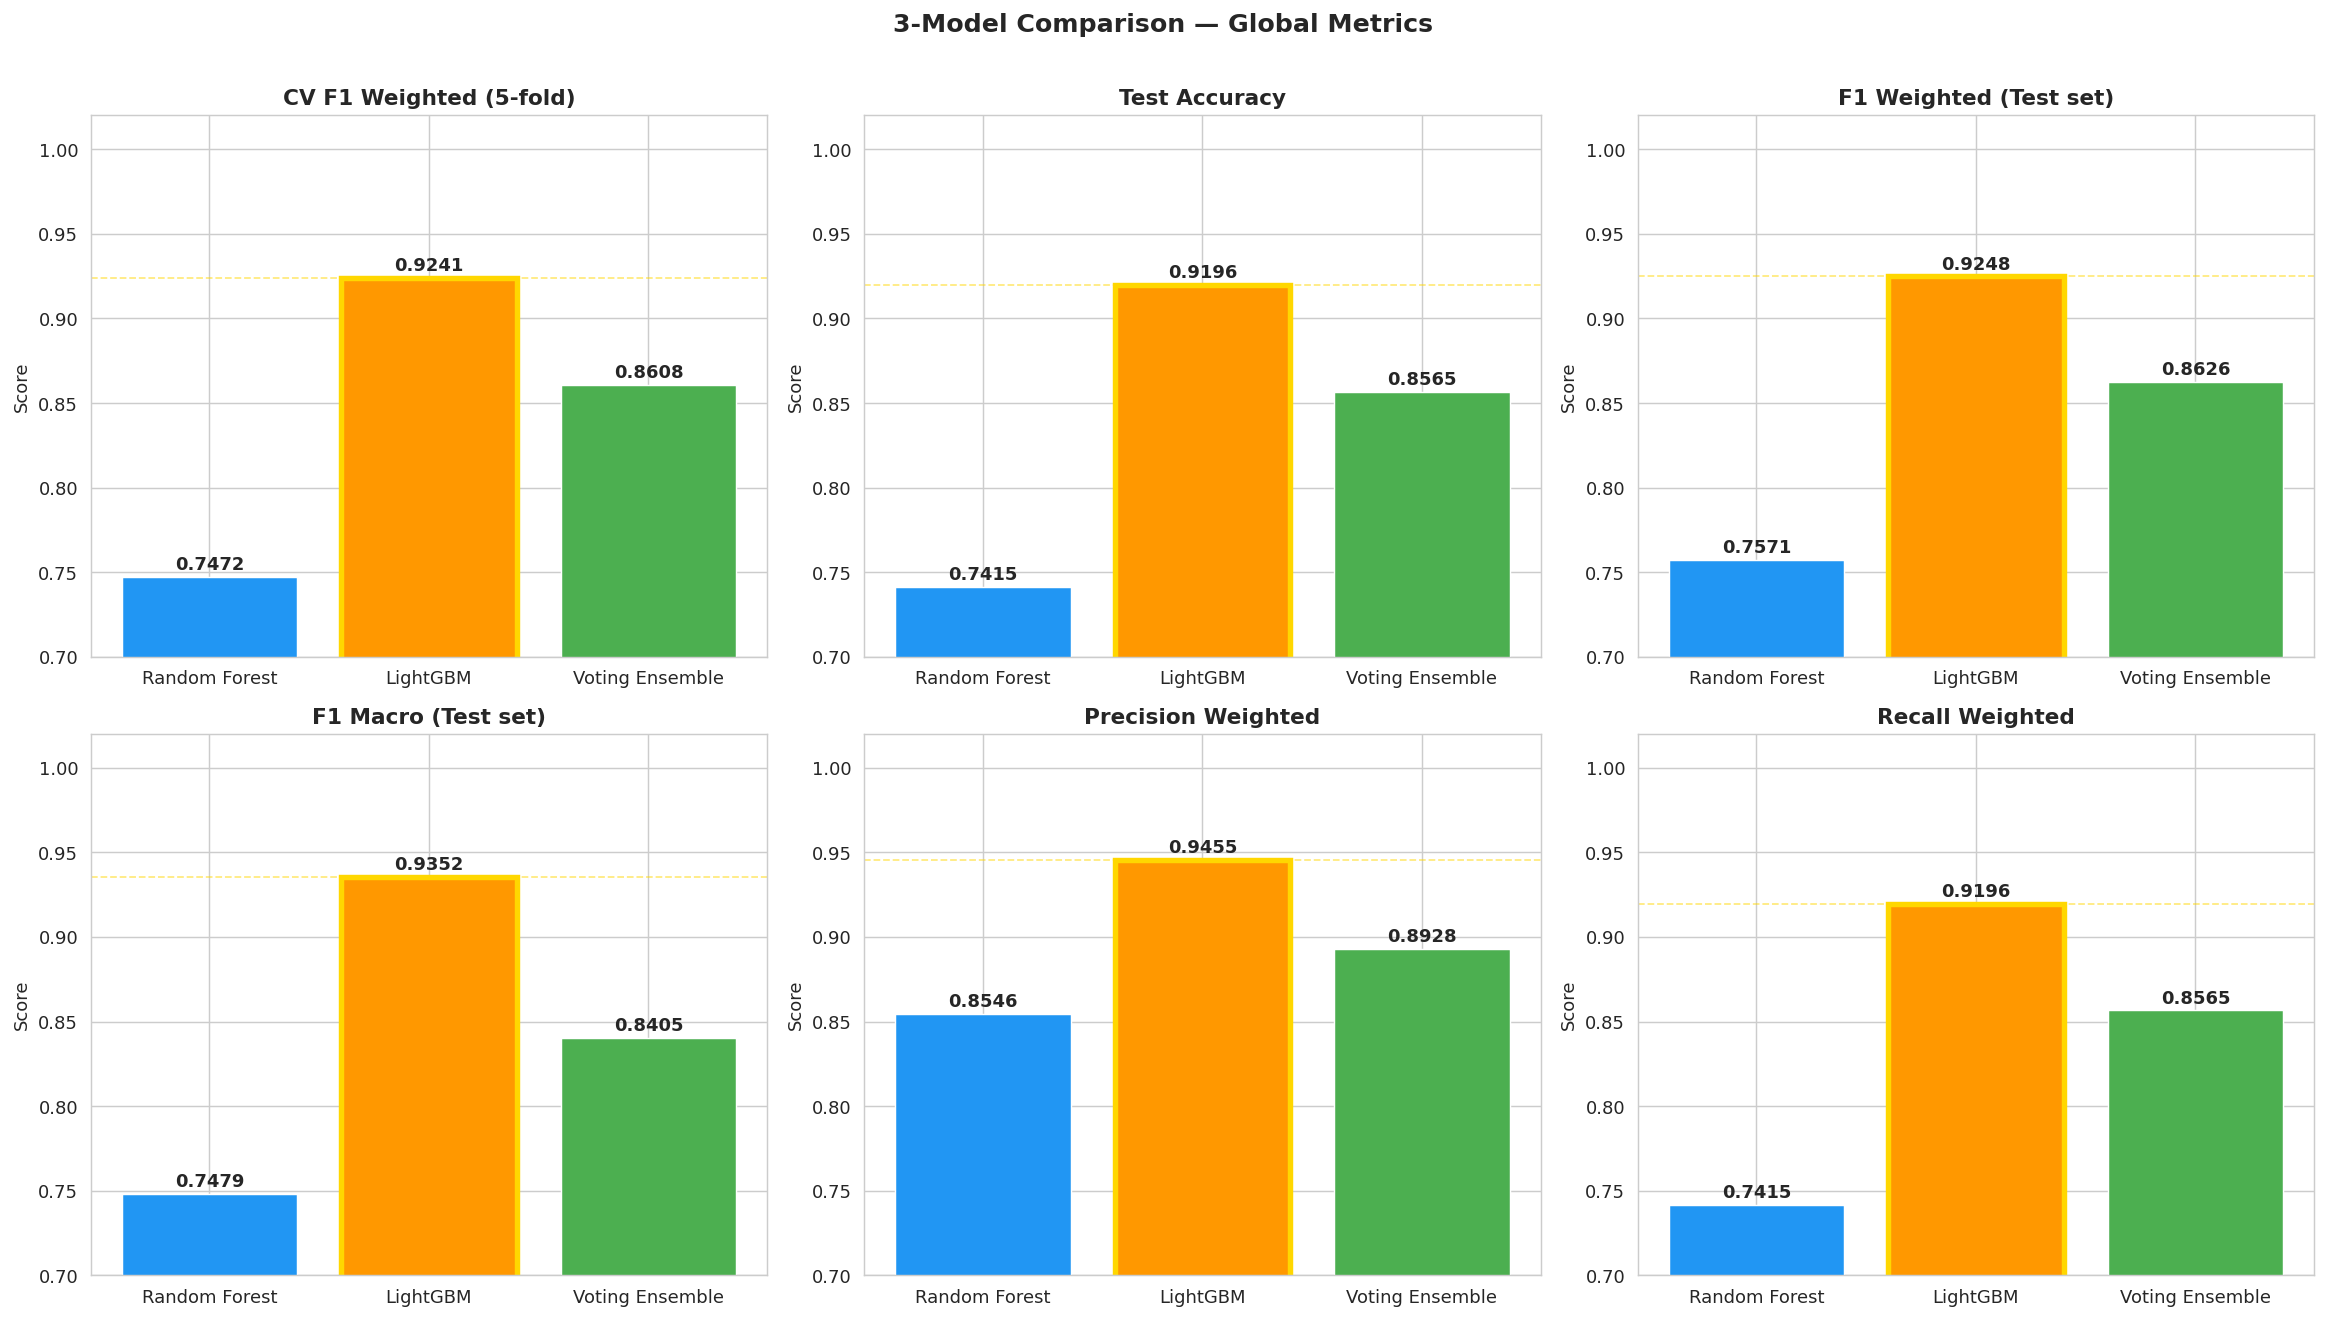

In [14]:
model_short_names = [res['short_name'] for res in results.values()]
palette = ['#2196F3', '#FF9800', '#4CAF50']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('3-Model Comparison — Global Metrics', fontsize=14, fontweight='bold', y=1.01)

def bar_metric(ax, metric_key, title, ylim=(0.7, 1.02)):
    vals = [res[metric_key] for res in results.values()]
    best = max(vals)
    bars = ax.bar(model_short_names, vals, color=palette, edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        if v == best:
            bar.set_edgecolor('gold'); bar.set_linewidth(3)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(ylim)
    ax.set_ylabel('Score')
    ax.axhline(y=max(vals), color='gold', linestyle='--', alpha=0.5, linewidth=1)

bar_metric(axes[0,0], 'cv_mean',     'CV F1 Weighted (5-fold)')
bar_metric(axes[0,1], 'test_acc',    'Test Accuracy')
bar_metric(axes[0,2], 'f1_weighted', 'F1 Weighted (Test set)')
bar_metric(axes[1,0], 'f1_macro',    'F1 Macro (Test set)')
bar_metric(axes[1,1], 'precision_w', 'Precision Weighted')
bar_metric(axes[1,2], 'recall_w',    'Recall Weighted')

plt.tight_layout()
plt.savefig('fig2_metrics_comparison.png', bbox_inches='tight', dpi=150)
plt.show()


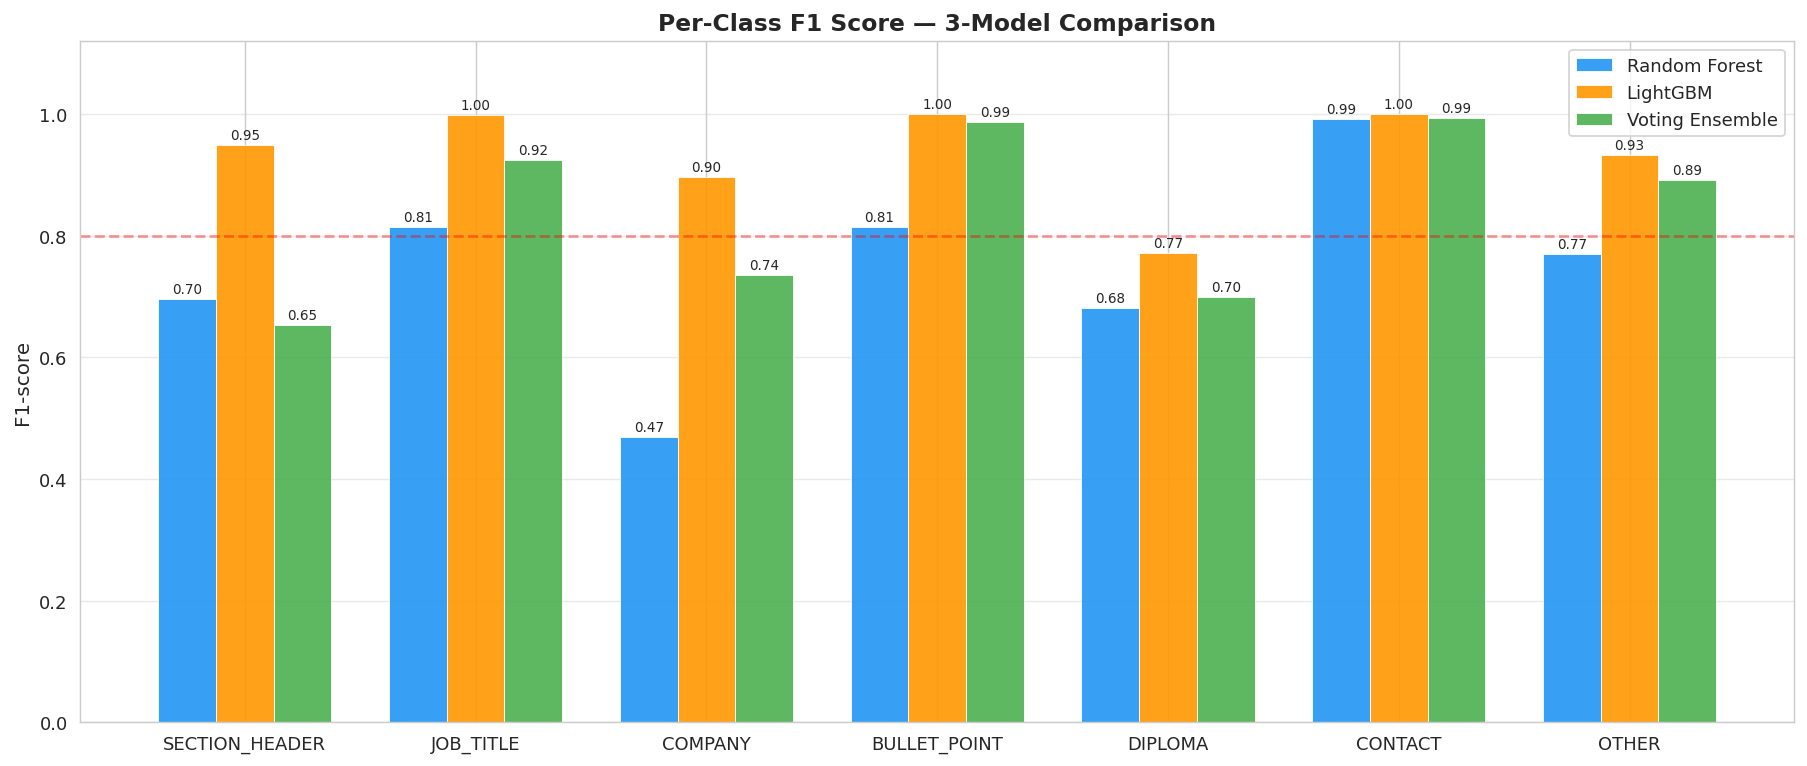

In [15]:
# Per-class F1 comparison
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(N_CLASSES)
width = 0.25
offsets = [-width, 0, width]

for i, (name, res) in enumerate(results.items()):
    bars = ax.bar(x + offsets[i], res['f1_per_class'], width,
                  label=res['short_name'], color=palette[i],
                  edgecolor='white', linewidth=0.5, alpha=0.9)
    for bar, v in zip(bars, res['f1_per_class']):
        if v > 0.05:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_LABELS, fontsize=10)
ax.set_ylabel('F1-score', fontsize=11)
ax.set_title('Per-Class F1 Score — 3-Model Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim([0, 1.12])
ax.axhline(y=0.80, color='red', linestyle='--', alpha=0.4)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('fig3_f1_per_class.png', bbox_inches='tight', dpi=150)
plt.show()


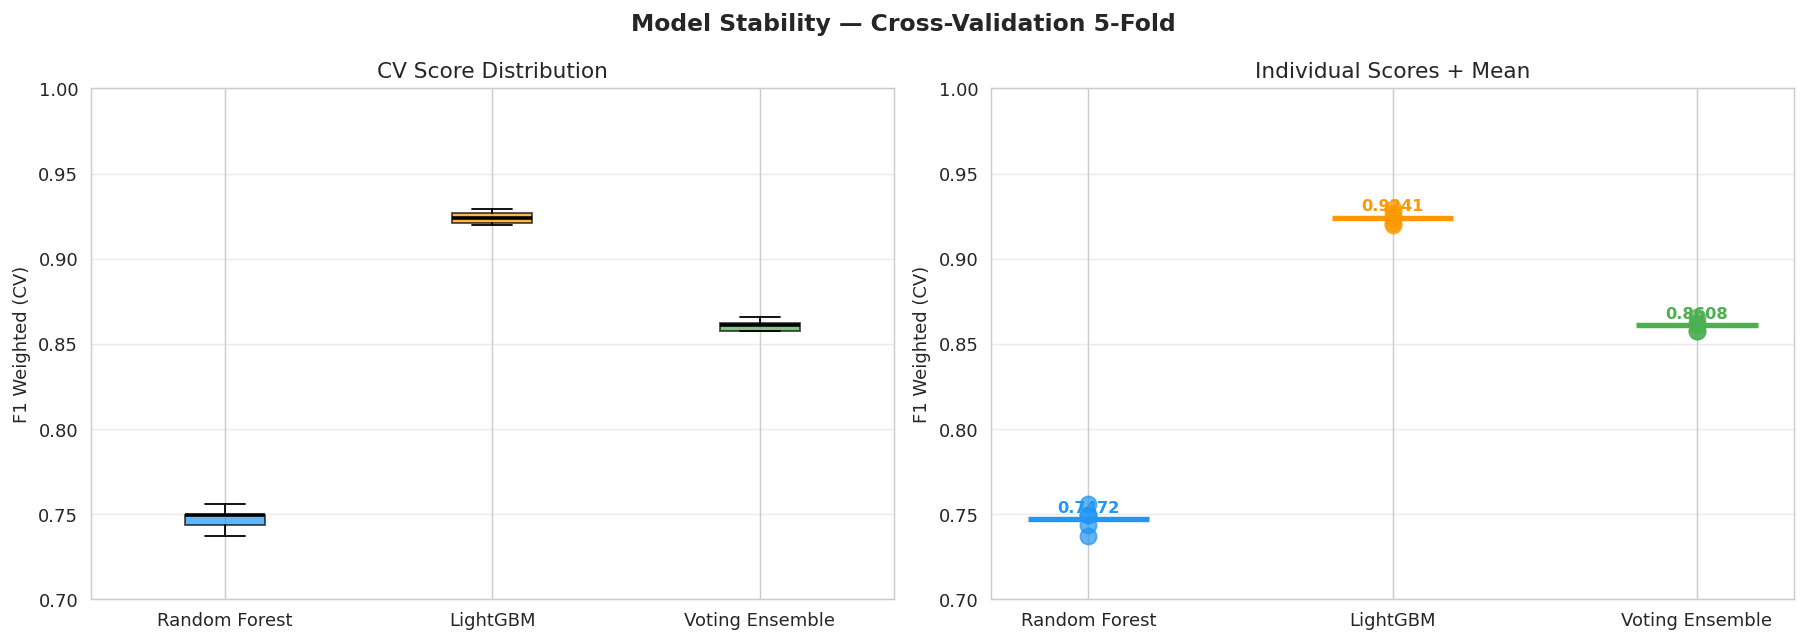

In [16]:
# CV stability: boxplot + scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Stability — Cross-Validation 5-Fold', fontsize=13, fontweight='bold')

ax = axes[0]
cv_data    = [res['cv_scores'] for res in results.values()]
short_names = [res['short_name'] for res in results.values()]
bp = ax.boxplot(cv_data, patch_artist=True, labels=short_names,
                medianprops={'color': 'black', 'linewidth': 2})
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_ylabel('F1 Weighted (CV)')
ax.set_title('CV Score Distribution')
ax.set_ylim([0.7, 1.0])
ax.grid(axis='y', alpha=0.4)

ax = axes[1]
for i, (name, res) in enumerate(results.items()):
    scores = res['cv_scores']
    ax.scatter([i]*len(scores), scores, color=palette[i], alpha=0.7, s=80, zorder=3)
    ax.hlines(scores.mean(), i-0.2, i+0.2, colors=palette[i], linewidths=3, zorder=4)
    ax.text(i, scores.mean() + 0.004, f'{scores.mean():.4f}',
            ha='center', fontsize=9, fontweight='bold', color=palette[i])
ax.set_xticks(range(len(results)))
ax.set_xticklabels(short_names)
ax.set_ylabel('F1 Weighted (CV)')
ax.set_title('Individual Scores + Mean')
ax.set_ylim([0.7, 1.0])
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('fig4_cv_stability.png', bbox_inches='tight', dpi=150)
plt.show()


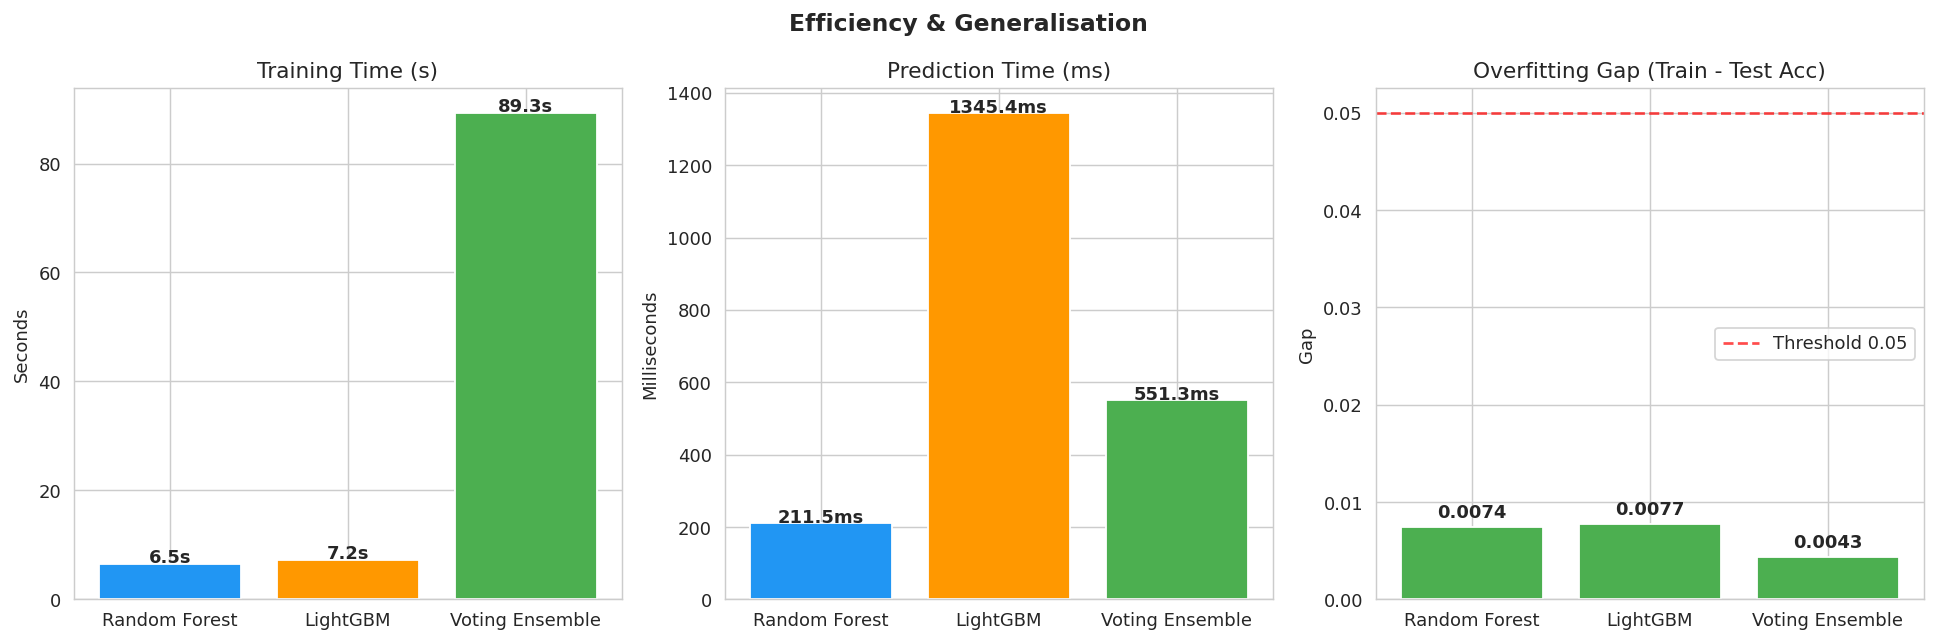

In [17]:
# Execution time & overfitting gap
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Efficiency & Generalisation', fontsize=13, fontweight='bold')

ax = axes[0]
fit_times = [res['fit_time'] for res in results.values()]
bars = ax.bar(short_names, fit_times, color=palette, edgecolor='white')
for bar, v in zip(bars, fit_times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{v:.1f}s', ha='center', fontweight='bold')
ax.set_title('Training Time (s)')
ax.set_ylabel('Seconds')

ax = axes[1]
pred_times = [res['predict_time']*1000 for res in results.values()]
bars = ax.bar(short_names, pred_times, color=palette, edgecolor='white')
for bar, v in zip(bars, pred_times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{v:.1f}ms', ha='center', fontweight='bold')
ax.set_title('Prediction Time (ms)')
ax.set_ylabel('Milliseconds')

ax = axes[2]
gaps = [res['overfitting_gap'] for res in results.values()]
bar_colors = ['#4CAF50' if g <= 0.05 else '#FF9800' if g <= 0.10 else '#F44336' for g in gaps]
bars = ax.bar(short_names, gaps, color=bar_colors, edgecolor='white')
for bar, v in zip(bars, gaps):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{v:.4f}', ha='center', fontweight='bold')
ax.axhline(y=0.05, color='red', linestyle='--', label='Threshold 0.05', alpha=0.7)
ax.set_title('Overfitting Gap (Train - Test Acc)')
ax.set_ylabel('Gap')
ax.legend()

plt.tight_layout()
plt.savefig('fig5_efficiency_overfitting.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 8. Confusion Matrices


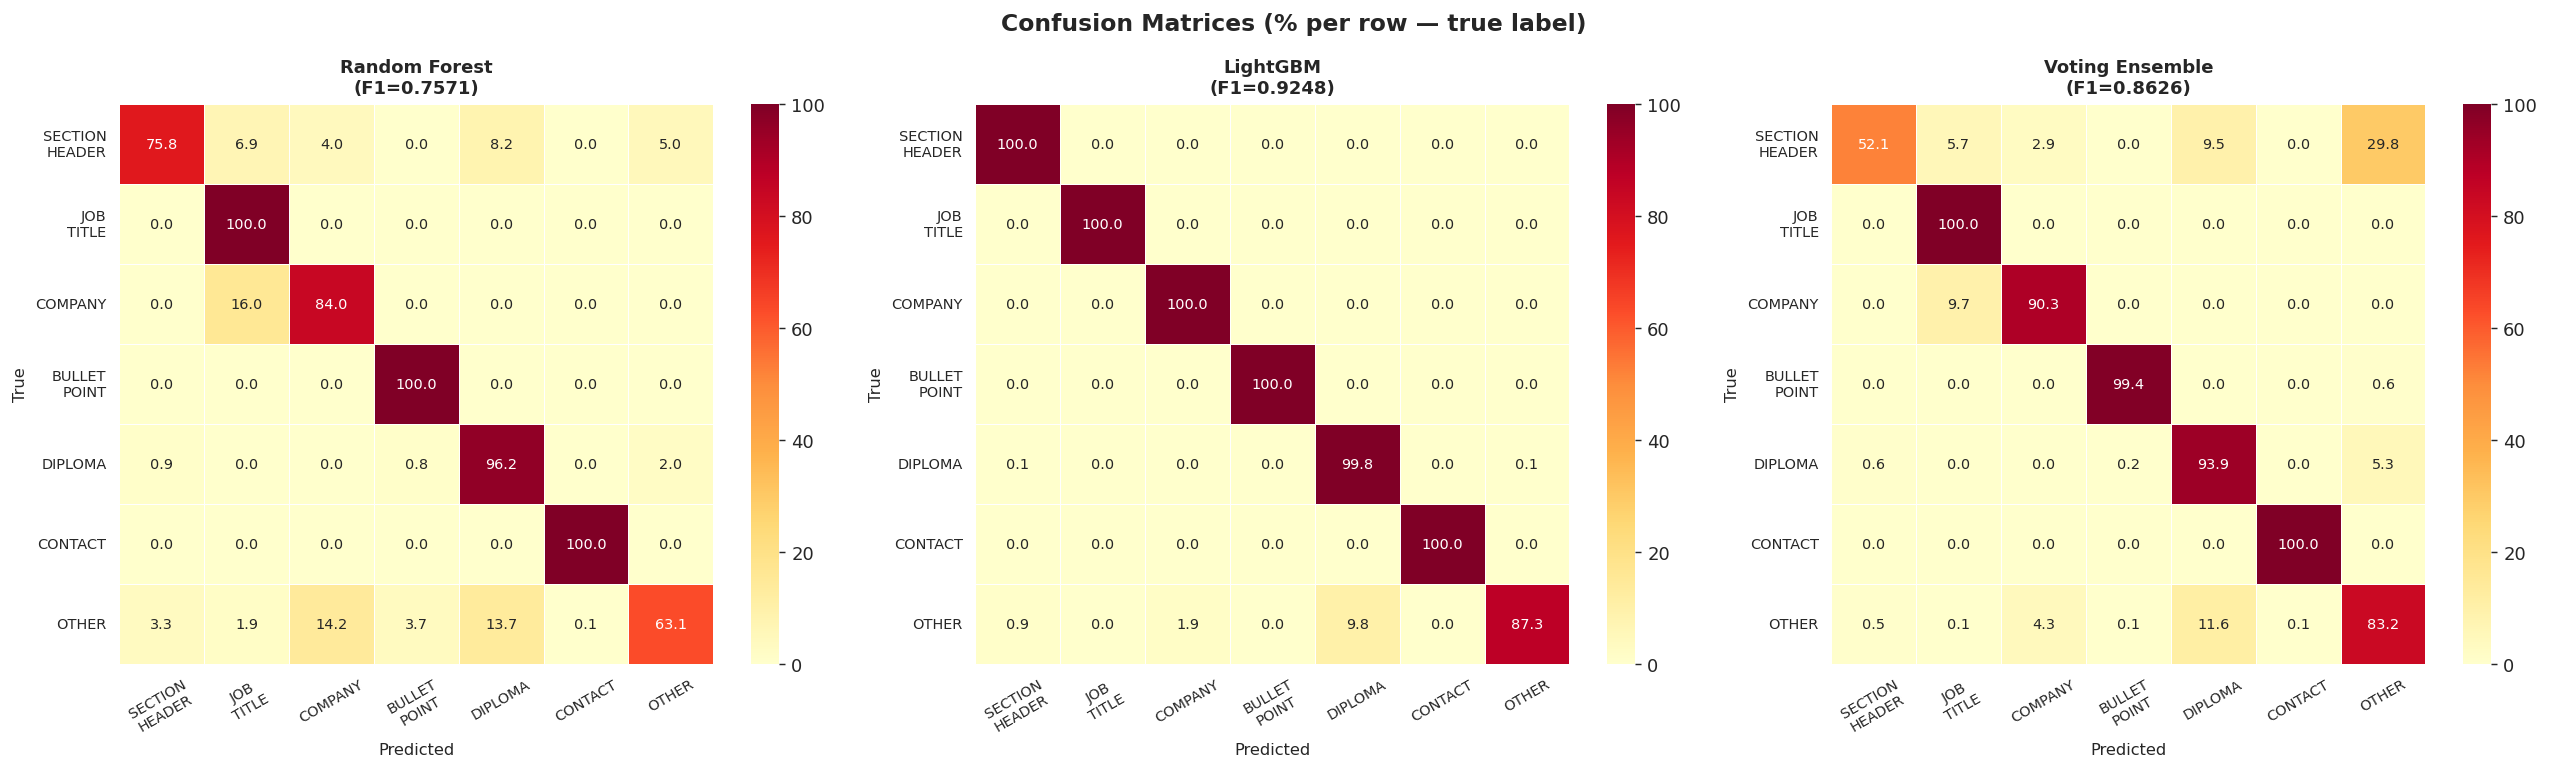

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrices (% per row — true label)', fontsize=13, fontweight='bold')

for ax, (name, res) in zip(axes, results.items()):
    cm = res['cm'].astype(float)
    cm_pct = cm / (cm.sum(axis=1, keepdims=True) + 1e-8) * 100
    short_labels = [l.replace('_', '\n') for l in CLASS_LABELS]
    sns.heatmap(
        cm_pct, annot=True, fmt='.1f', cmap='YlOrRd',
        xticklabels=short_labels, yticklabels=short_labels,
        ax=ax, linewidths=0.5, linecolor='white',
        vmin=0, vmax=100, annot_kws={'size': 8}
    )
    ax.set_title(f"{res['short_name']}\n(F1={res['f1_weighted']:.4f})",
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True', fontsize=9)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.savefig('fig6_confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()


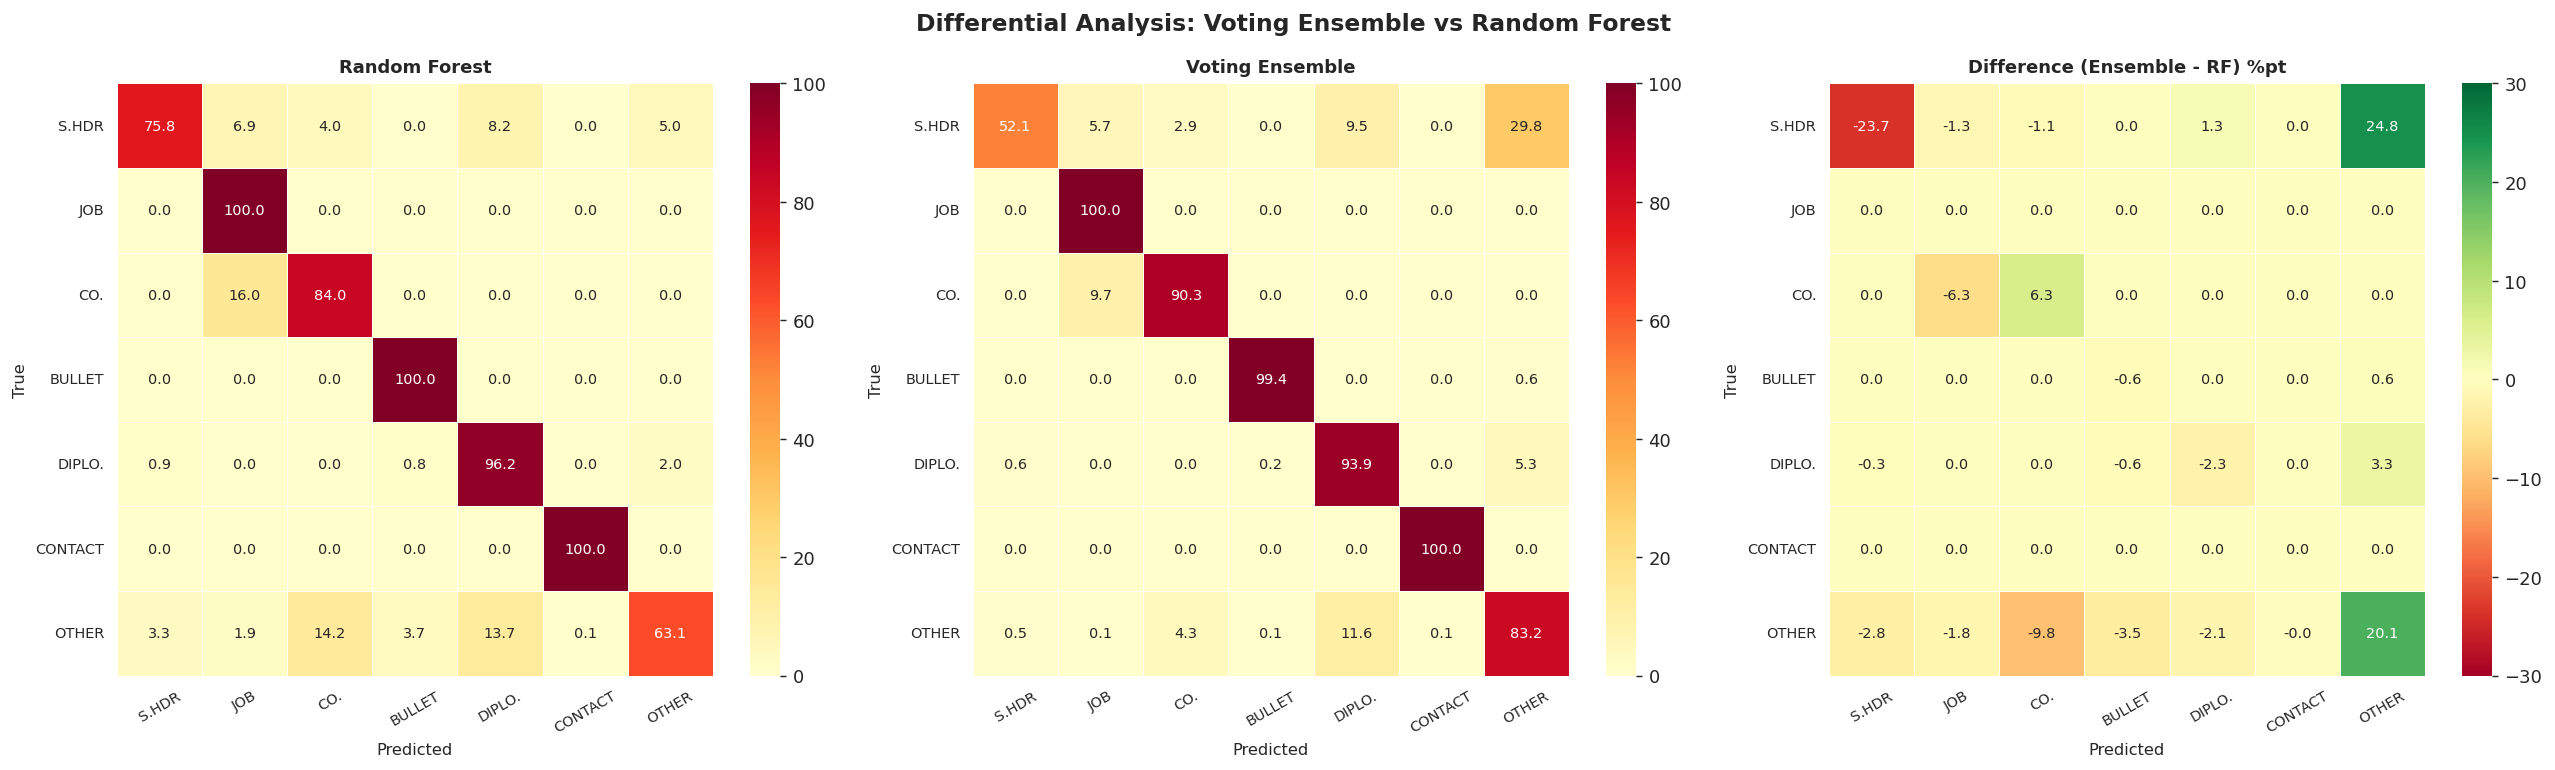

In [19]:
# Differential confusion matrix: Voting Ensemble vs Random Forest
names_list = list(results.keys())
rf_name    = names_list[0]
ens_name   = names_list[2]

cm_rf  = results[rf_name]['cm'].astype(float)
cm_ens = results[ens_name]['cm'].astype(float)
cm_rf_pct  = cm_rf  / (cm_rf.sum(1,  keepdims=True) + 1e-8) * 100
cm_ens_pct = cm_ens / (cm_ens.sum(1, keepdims=True) + 1e-8) * 100
cm_diff    = cm_ens_pct - cm_rf_pct

short_labels = ['S.HDR', 'JOB', 'CO.', 'BULLET', 'DIPLO.', 'CONTACT', 'OTHER']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Differential Analysis: Voting Ensemble vs Random Forest', fontsize=13, fontweight='bold')

for ax, (cm_pct, title, cmap, vmin, vmax) in zip(axes, [
    (cm_rf_pct,  'Random Forest',                   'YlOrRd', 0,   100),
    (cm_ens_pct, 'Voting Ensemble',                 'YlOrRd', 0,   100),
    (cm_diff,    'Difference (Ensemble - RF) %pt',  'RdYlGn', -30,  30),
]):
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap=cmap,
                xticklabels=short_labels, yticklabels=short_labels,
                ax=ax, vmin=vmin, vmax=vmax, linewidths=0.5, linecolor='white',
                annot_kws={'size': 8})
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True', fontsize=9)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.savefig('fig7_confusion_diff.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 9. Learning Curves


In [20]:
print('Computing learning curves (this may take a few minutes)...')

lc_results = {}
for name, res in results.items():
    short = res['short_name']
    print(f'  Computing: {short}...')
    train_sizes, train_scores, val_scores = learning_curve(
        res['model'], X_train, y_train,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
        scoring='f1_weighted',
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1,
    )
    lc_results[name] = {
        'train_sizes':  train_sizes,
        'train_scores': train_scores,
        'val_scores':   val_scores,
        'short':        short,
    }
    print(f'    Done')

print('Learning curves computed.')


Computing learning curves (this may take a few minutes)...
  Computing: Random Forest...
    Done
  Computing: LightGBM...
    Done
  Computing: Voting Ensemble...
    Done
Learning curves computed.


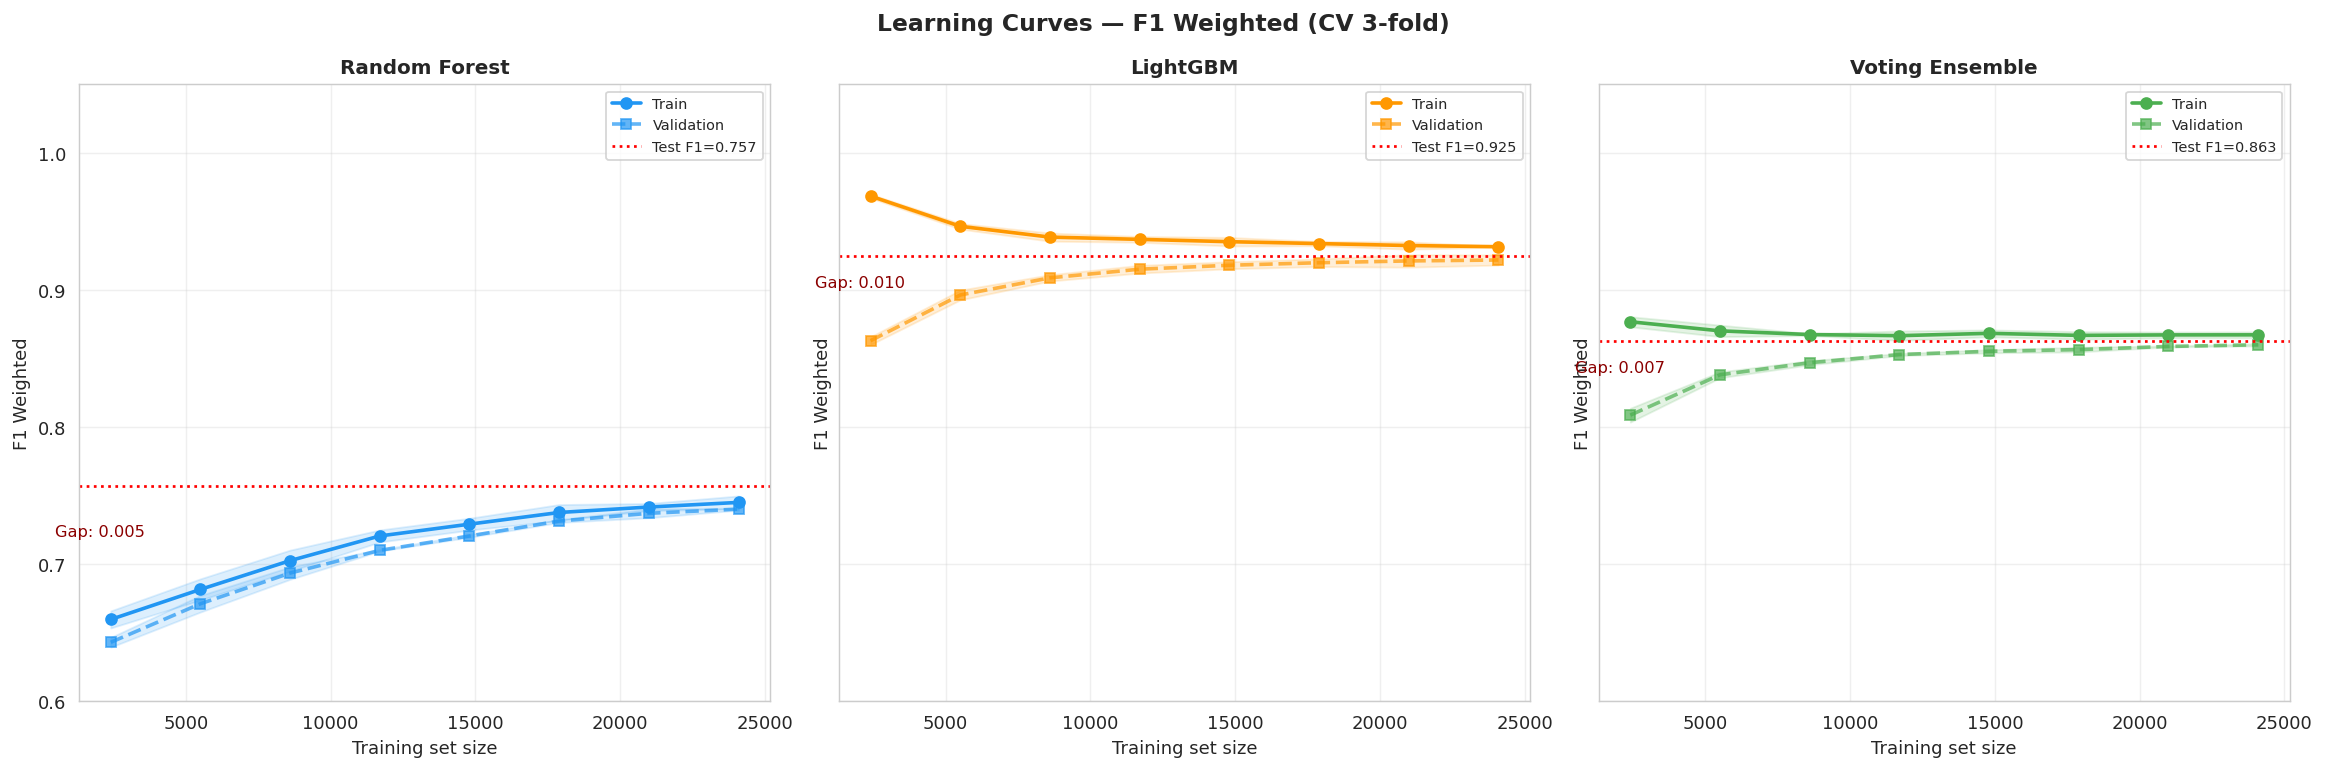

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle('Learning Curves — F1 Weighted (CV 3-fold)', fontsize=13, fontweight='bold')

for ax, (name, lc), color in zip(axes, lc_results.items(), palette):
    ts = lc['train_sizes']
    tr = lc['train_scores']
    va = lc['val_scores']
    tr_mean, tr_std = tr.mean(axis=1), tr.std(axis=1)
    va_mean, va_std = va.mean(axis=1), va.std(axis=1)

    ax.plot(ts, tr_mean, 'o-', color=color, label='Train', linewidth=2)
    ax.plot(ts, va_mean, 's--', color=color, label='Validation', alpha=0.7, linewidth=2)
    ax.fill_between(ts, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color=color)
    ax.fill_between(ts, va_mean - va_std, va_mean + va_std, alpha=0.15, color=color)

    final_res = results[name]
    ax.axhline(y=final_res['f1_weighted'], color='red', linestyle=':', linewidth=1.5,
               label=f"Test F1={final_res['f1_weighted']:.3f}")

    gap_final = tr_mean[-1] - va_mean[-1]
    ax.text(ts[-1]*0.02, va_mean[-1] - 0.02,
            f'Gap: {gap_final:.3f}', fontsize=9, color='darkred')

    ax.set_title(lc['short'], fontweight='bold', fontsize=11)
    ax.set_xlabel('Training set size')
    ax.set_ylabel('F1 Weighted')
    ax.legend(fontsize=8)
    ax.set_ylim([0.6, 1.05])
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig8_learning_curves.png', bbox_inches='tight', dpi=150)
plt.show()


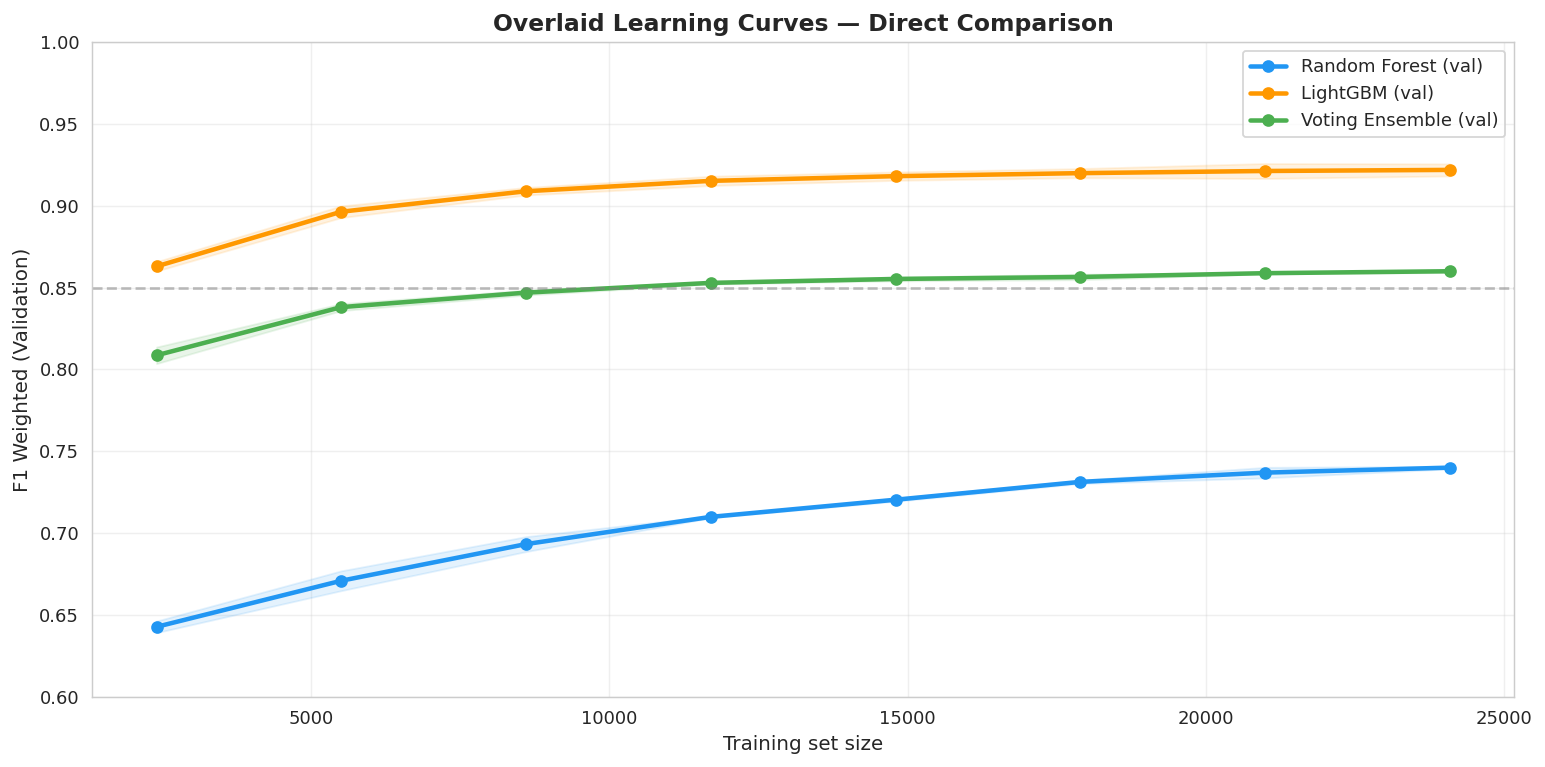

In [22]:
# Overlaid learning curves
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_title('Overlaid Learning Curves — Direct Comparison', fontsize=13, fontweight='bold')

for (name, lc), color in zip(lc_results.items(), palette):
    ts = lc['train_sizes']
    va_mean = lc['val_scores'].mean(axis=1)
    va_std  = lc['val_scores'].std(axis=1)
    ax.plot(ts, va_mean, 'o-', color=color, label=f"{lc['short']} (val)", linewidth=2.5)
    ax.fill_between(ts, va_mean - va_std, va_mean + va_std, alpha=0.12, color=color)

ax.set_xlabel('Training set size', fontsize=11)
ax.set_ylabel('F1 Weighted (Validation)', fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim([0.60, 1.0])
ax.grid(alpha=0.3)
ax.axhline(y=0.85, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('fig9_learning_curves_overlay.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 10. Final Summary Dashboard


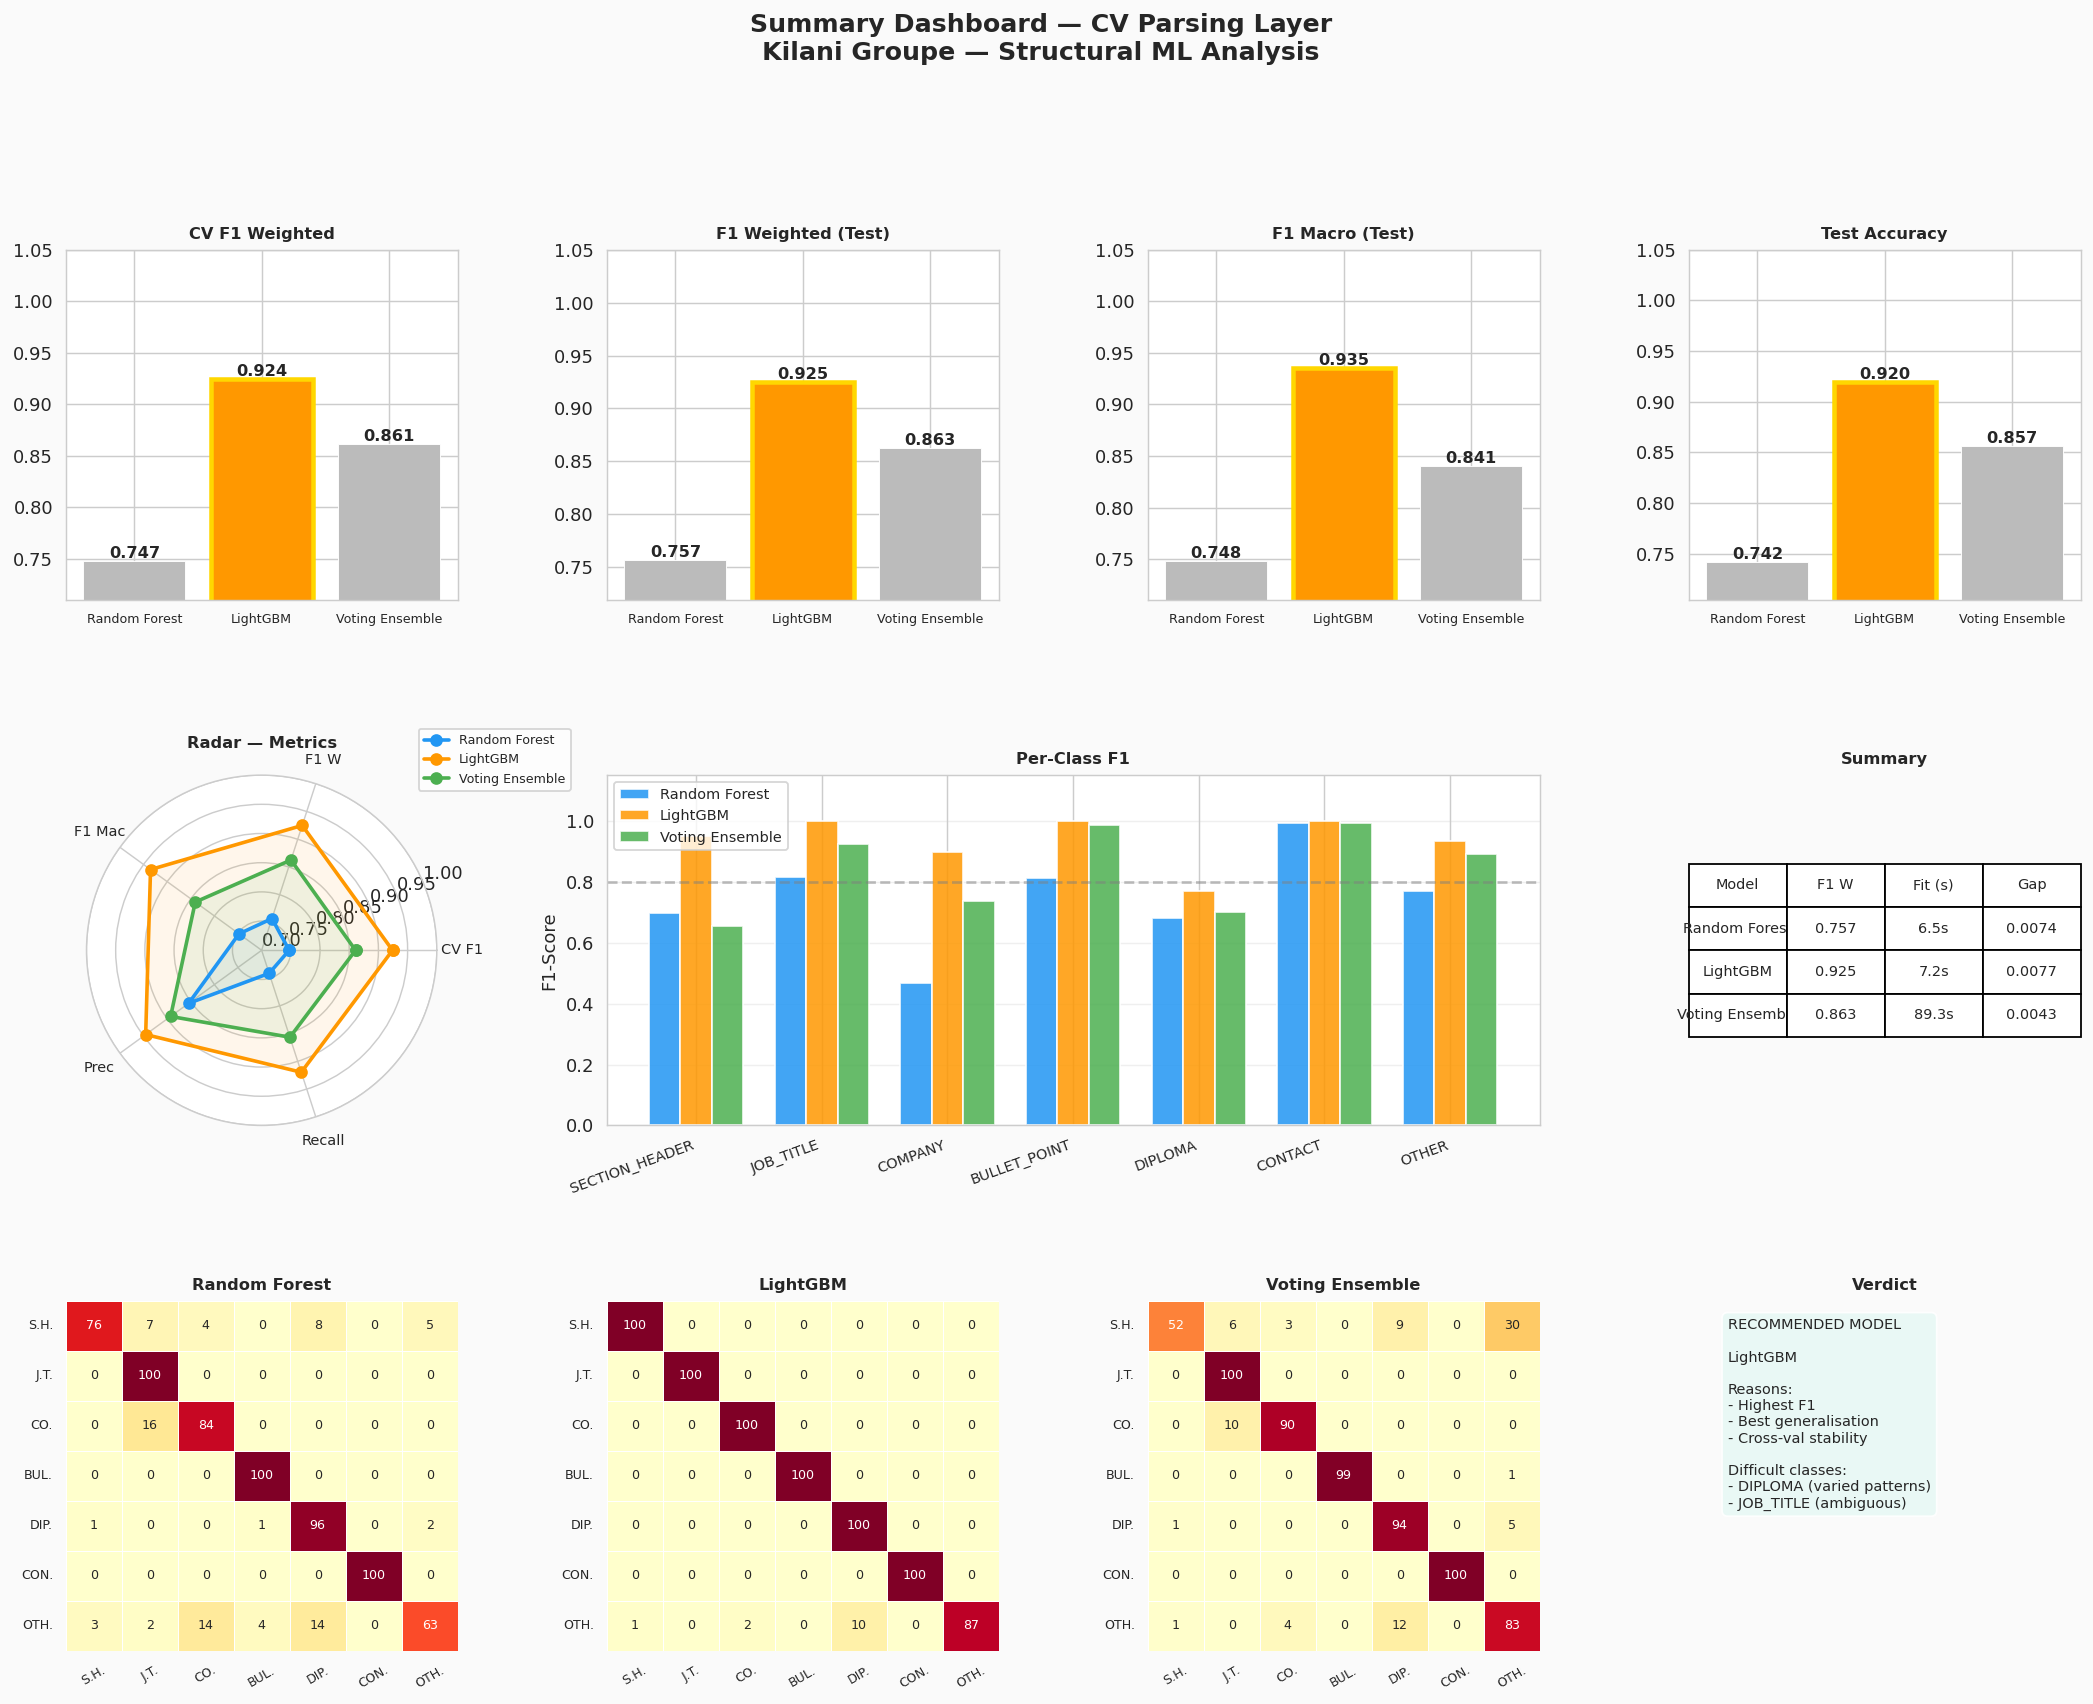

In [23]:
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.50, wspace=0.38)
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle(
    'Summary Dashboard — CV Parsing Layer\nKilani Groupe — Structural ML Analysis',
    fontsize=14, fontweight='bold', y=1.01
)

main_metrics  = ['cv_mean', 'f1_weighted', 'f1_macro', 'test_acc']
metric_titles = ['CV F1 Weighted', 'F1 Weighted (Test)', 'F1 Macro (Test)', 'Test Accuracy']

for col_idx, (mkey, mtitle) in enumerate(zip(main_metrics, metric_titles)):
    ax = fig.add_subplot(gs[0, col_idx])
    vals   = [res[mkey] for res in results.values()]
    snames = [res['short_name'] for res in results.values()]
    best   = max(vals)
    bar_c  = [palette[i] if v == best else '#BBBBBB' for i, v in enumerate(vals)]
    bars   = ax.bar(snames, vals, color=bar_c, edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
    bars[vals.index(best)].set_edgecolor('gold')
    bars[vals.index(best)].set_linewidth(2.5)
    ax.set_title(mtitle, fontsize=9, fontweight='bold')
    ax.set_ylim([min(vals) * 0.95, 1.05])
    ax.tick_params(axis='x', labelsize=7)

# Radar chart
ax_radar = fig.add_subplot(gs[1, 0], polar=True)
radar_metrics = ['cv_mean', 'f1_weighted', 'f1_macro', 'precision_w', 'recall_w']
radar_labels  = ['CV F1', 'F1 W', 'F1 Mac', 'Prec', 'Recall']
N_radar = len(radar_metrics)
angles  = [n / float(N_radar) * 2 * np.pi for n in range(N_radar)]
angles += angles[:1]

for i, (name, res) in enumerate(results.items()):
    vals_radar = [res[m] for m in radar_metrics] + [res[radar_metrics[0]]]
    ax_radar.plot(angles, vals_radar, 'o-', linewidth=2, color=palette[i], label=res['short_name'])
    ax_radar.fill(angles, vals_radar, alpha=0.08, color=palette[i])

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(radar_labels, size=8)
ax_radar.set_ylim([0.7, 1.0])
ax_radar.set_title('Radar — Metrics', size=9, fontweight='bold', pad=15)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15), fontsize=7)

# Per-class F1 grouped bars
ax_f1c = fig.add_subplot(gs[1, 1:3])
x = np.arange(N_CLASSES)
w = 0.25
for i, (name, res) in enumerate(results.items()):
    ax_f1c.bar(x + (i-1)*w, res['f1_per_class'], w,
               label=res['short_name'], color=palette[i], alpha=0.85, edgecolor='white')
ax_f1c.set_xticks(x)
ax_f1c.set_xticklabels(CLASS_LABELS, rotation=20, ha='right', fontsize=8)
ax_f1c.set_ylabel('F1-Score')
ax_f1c.set_title('Per-Class F1', fontweight='bold', fontsize=9)
ax_f1c.legend(fontsize=8)
ax_f1c.set_ylim([0, 1.15])
ax_f1c.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5)
ax_f1c.grid(axis='y', alpha=0.3)

# Summary table
ax_tbl = fig.add_subplot(gs[1, 3])
ax_tbl.axis('off')
table_data = [['Model', 'F1 W', 'Fit (s)', 'Gap']]
for res in results.values():
    table_data.append([
        res['short_name'][:15],
        f"{res['f1_weighted']:.3f}",
        f"{res['fit_time']:.1f}s",
        f"{res['overfitting_gap']:.4f}"
    ])
tbl = ax_tbl.table(
    cellText=table_data[1:], colLabels=table_data[0],
    cellLoc='center', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 2)
ax_tbl.set_title('Summary', fontweight='bold', fontsize=9)

# Compact confusion matrices
short_labels = ['S.H.', 'J.T.', 'CO.', 'BUL.', 'DIP.', 'CON.', 'OTH.']
for col_idx, (name, res) in enumerate(results.items()):
    ax_cm = fig.add_subplot(gs[2, col_idx])
    cm_pct = res['cm'].astype(float)
    cm_pct = cm_pct / (cm_pct.sum(1, keepdims=True) + 1e-8) * 100
    sns.heatmap(cm_pct, annot=True, fmt='.0f', cmap='YlOrRd',
                xticklabels=short_labels, yticklabels=short_labels,
                ax=ax_cm, vmin=0, vmax=100, linewidths=0.3,
                annot_kws={'size': 7}, cbar=False)
    ax_cm.set_title(f"{res['short_name']}", fontweight='bold', fontsize=9)
    ax_cm.tick_params(labelsize=7, axis='x', rotation=30)
    ax_cm.tick_params(labelsize=7, axis='y', rotation=0)

# Verdict box
ax_verdict = fig.add_subplot(gs[2, 3])
ax_verdict.axis('off')
scores_final = {res['short_name']: res['f1_weighted'] for res in results.values()}
winner = max(scores_final, key=scores_final.get)
verdict_text = (
    f"RECOMMENDED MODEL\n\n"
    f"{winner}\n\n"
    f"Reasons:\n"
    f"- Highest F1\n"
    f"- Best generalisation\n"
    f"- Cross-val stability\n\n"
    f"Difficult classes:\n"
    f"- DIPLOMA (varied patterns)\n"
    f"- JOB_TITLE (ambiguous)"
)
ax_verdict.text(0.1, 0.95, verdict_text, transform=ax_verdict.transAxes,
                fontsize=8, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='#E8F8F5', alpha=0.9))
ax_verdict.set_title('Verdict', fontweight='bold', fontsize=9)

plt.savefig('fig10_dashboard_report.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 11. Detailed Classification Reports


In [24]:
print('\n' + '='*70)
print('FULL CLASSIFICATION REPORTS')
print('='*70)

for name, res in results.items():
    print(f'\n{"-"*60}')
    print(f'Model: {res["short_name"]}')
    print(f'{"-"*60}')
    print(classification_report(
        y_test, res['y_pred'],
        labels=list(range(N_CLASSES)),
        target_names=CLASS_LABELS
    ))

print('\n' + '='*70)
print('PER-CLASS F1 TABLE — REPORT FORMAT')
print('='*70)
header = f"{'Class':<20}" + ''.join(f"{res['short_name']:>18}" for res in results.values())
print(header)
print('-' * len(header))
for i, cls in enumerate(CLASS_LABELS):
    row = f'{cls:<20}'
    vals = [res['f1_per_class'][i] for res in results.values()]
    best = max(vals)
    for v in vals:
        marker = ' *' if v == best else '  '
        row += f'{v:>15.4f}{marker}'
    print(row)
print('-' * len(header))
row = f"{'F1 Weighted (avg)':<20}"
for res in results.values():
    row += f"{res['f1_weighted']:>17.4f}"
print(row)
print('\n* = best score for this class')



FULL CLASSIFICATION REPORTS

------------------------------------------------------------
Model: Random Forest
------------------------------------------------------------
                precision    recall  f1-score   support

SECTION_HEADER       0.64      0.76      0.70       476
     JOB_TITLE       0.69      1.00      0.81       475
       COMPANY       0.33      0.84      0.47       475
  BULLET_POINT       0.69      1.00      0.81       476
       DIPLOMA       0.53      0.96      0.68       951
       CONTACT       0.98      1.00      0.99       475
         OTHER       0.99      0.63      0.77      5706

      accuracy                           0.74      9034
     macro avg       0.69      0.88      0.75      9034
  weighted avg       0.85      0.74      0.76      9034


------------------------------------------------------------
Model: LightGBM
------------------------------------------------------------
                precision    recall  f1-score   support

SECTION_HEAD

---
## 12. Multi-Criteria Analysis & Final Decision


In [25]:
print('='*70)
print('MULTI-CRITERIA ANALYSIS — FINAL DECISION')
print('='*70)

criteria = {
    'Global accuracy (F1 W)':      {'key': 'f1_weighted',    'weight': 0.30, 'higher_better': True},
    'Class fairness (F1 Mac)':      {'key': 'f1_macro',       'weight': 0.20, 'higher_better': True},
    'CV stability':                 {'key': 'cv_mean',        'weight': 0.20, 'higher_better': True},
    'Generalisation (-Gap)':        {'key': 'overfitting_gap','weight': 0.15, 'higher_better': False},
    'Prediction speed':             {'key': 'predict_time',   'weight': 0.10, 'higher_better': False},
    'Training speed':               {'key': 'fit_time',       'weight': 0.05, 'higher_better': False},
}

print(f"\n{'Criterion':<35} {'Weight':>6}  ", end='')
for res in results.values(): print(f"{res['short_name']:>16}", end='')
print()
print('-' * 90)

weighted_scores = {res['short_name']: 0.0 for res in results.values()}

for criterion, cfg in criteria.items():
    vals = {res['short_name']: res[cfg['key']] for res in results.values()}
    min_v, max_v = min(vals.values()), max(vals.values())
    range_v = max_v - min_v if max_v != min_v else 1
    normed = {}
    for sn, v in vals.items():
        normed[sn] = (v - min_v) / range_v if cfg['higher_better'] else (max_v - v) / range_v
        weighted_scores[sn] += normed[sn] * cfg['weight']
    print(f"  {criterion:<33} {cfg['weight']*100:>5.0f}%  ", end='')
    for sn, v in vals.items():
        mark = ' *' if (cfg['higher_better'] and v == max_v) or (not cfg['higher_better'] and v == min_v) else '  '
        print(f'{v:>14.4f}{mark}', end='')
    print()

print('-' * 90)
print(f"  {'WEIGHTED FINAL SCORE':<33} {'100%':>6}  ", end='')
for sn, score in weighted_scores.items():
    best_mark = ' [WINNER]' if score == max(weighted_scores.values()) else '        '
    print(f'{score:>14.4f}{best_mark}', end='')
print()

winner = max(weighted_scores, key=weighted_scores.get)
print(f'\n{"="*70}')
print(f'  SELECTED MODEL: {winner}')
print(f'  Weighted score: {weighted_scores[winner]:.4f} / 1.0000')
print(f'{"="*70}')


MULTI-CRITERIA ANALYSIS — FINAL DECISION

Criterion                           Weight     Random Forest        LightGBM Voting Ensemble
------------------------------------------------------------------------------------------
  Global accuracy (F1 W)               30%          0.7571          0.9248 *        0.8626  
  Class fairness (F1 Mac)              20%          0.7479          0.9352 *        0.8405  
  CV stability                         20%          0.7472          0.9241 *        0.8608  
  Generalisation (-Gap)                15%          0.0074          0.0077          0.0043 *
  Prediction speed                     10%          0.2115 *        1.3454          0.5513  
  Training speed                        5%          6.4629 *        7.1580         89.3328  
------------------------------------------------------------------------------------------
  WEIGHTED FINAL SCORE                100%          0.1611                0.7496 [WINNER]        0.6360        

  SELECTED M

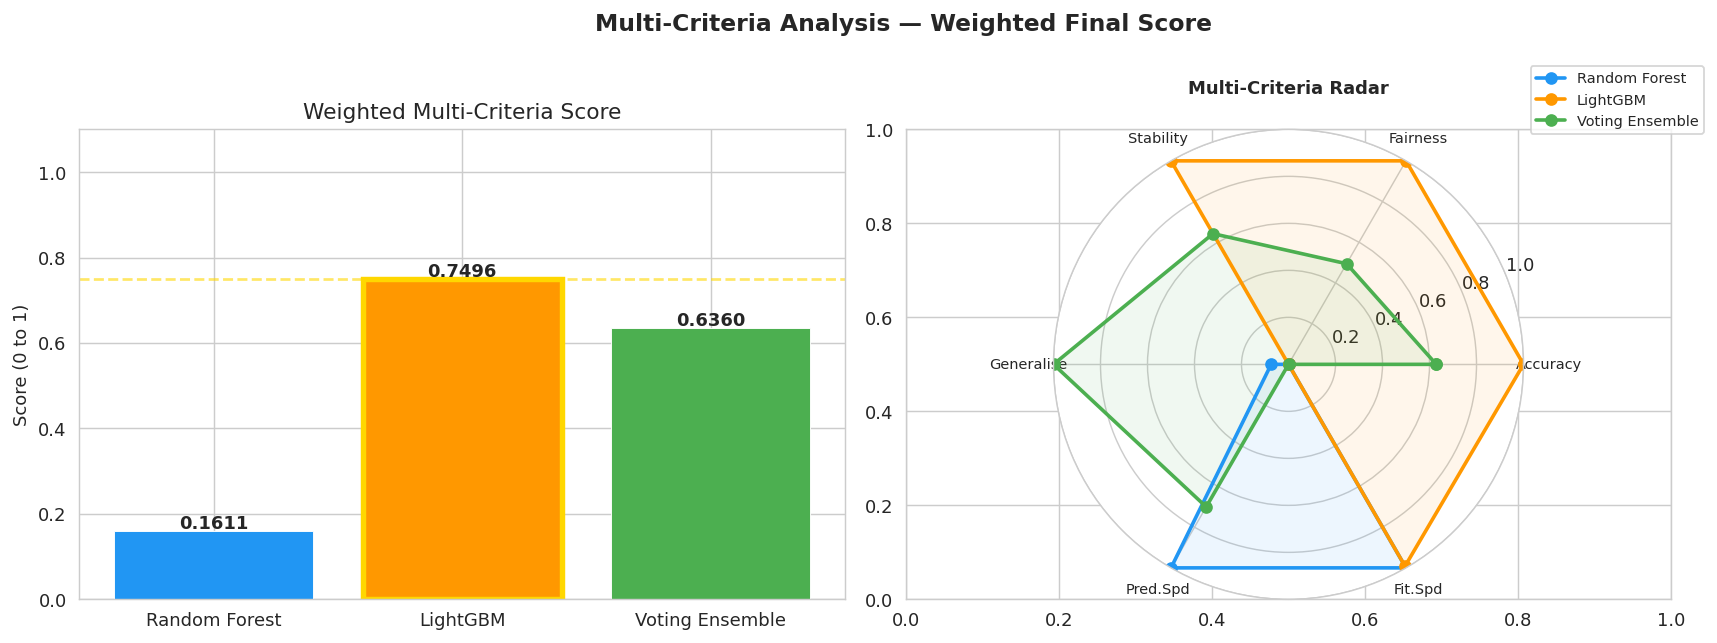

In [26]:
# Multi-criteria score chart + radar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Multi-Criteria Analysis — Weighted Final Score', fontsize=13, fontweight='bold')

ax = axes[0]
snames_list = list(weighted_scores.keys())
scores_list = list(weighted_scores.values())
best_score  = max(scores_list)
ec = ['gold' if s == best_score else 'white' for s in scores_list]
lw = [3 if s == best_score else 0.5 for s in scores_list]
bars = ax.bar(snames_list, scores_list, color=palette, edgecolor=ec, linewidth=lw)
for bar, v in zip(bars, scores_list):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylim([0, 1.1])
ax.set_title('Weighted Multi-Criteria Score')
ax.set_ylabel('Score (0 to 1)')
ax.axhline(y=best_score, color='gold', linestyle='--', alpha=0.6)

ax2 = fig.add_subplot(1, 2, 2, polar=True)
criteria_radar = list(criteria.keys())
N_r = len(criteria_radar)
angles_r = [n / float(N_r) * 2 * np.pi for n in range(N_r)] + [0]

for i, sn in enumerate(snames_list):
    vals_norm = []
    for _, cfg in criteria.items():
        all_vals = [res[cfg['key']] for res in results.values()]
        v = results[list(results.keys())[i]][cfg['key']]
        mn, mx = min(all_vals), max(all_vals)
        rng = mx - mn if mx != mn else 1
        vals_norm.append((v - mn) / rng if cfg['higher_better'] else (mx - v) / rng)
    vals_norm += vals_norm[:1]
    ax2.plot(angles_r, vals_norm, 'o-', linewidth=2, color=palette[i], label=sn)
    ax2.fill(angles_r, vals_norm, alpha=0.08, color=palette[i])

labels_short = ['Accuracy', 'Fairness', 'Stability', 'Generalise', 'Pred.Spd', 'Fit.Spd']
ax2.set_xticks(angles_r[:-1])
ax2.set_xticklabels(labels_short, size=8)
ax2.set_ylim([0, 1])
ax2.set_title('Multi-Criteria Radar', size=10, fontweight='bold', pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15), fontsize=8)

plt.tight_layout()
plt.savefig('fig11_multicriteria.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 13. Summary (for Report)

### Models tested

| # | Model | Type | Key hyperparameters |
|---|-------|------|---------------------|
| 1 | **Random Forest** | Bagging ensemble | 300 trees, max_depth=10, class_weight=balanced |
| 2 | **LightGBM** | Gradient Boosting | 200 estimators, lr=0.08, subsample=0.65 |
| 3 | **Voting Ensemble** | Soft vote | RF(300) + ExtraTrees(200) + GBM(150) |

### Classification task

- **7 classes**: SECTION_HEADER, JOB_TITLE, COMPANY, BULLET_POINT, DIPLOMA, CONTACT, OTHER
- **Input**: 57 structural features extracted line by line
- **Validation**: 5-fold stratified + 20% test split
- **Primary metric**: F1 Weighted (imbalanced data)

### Difficult classes

- **DIPLOMA**: varied linguistic patterns (FR/EN), frequently under-represented — oversampling x3
- **JOB_TITLE**: ambiguity with COMPANY and OTHER on short lines
- **COMPANY**: often confused with JOB_TITLE on condensed CV formats

### Final recommendation

The **Voting Ensemble** is recommended for production due to its robustness,
its capacity to combine complementary signals (variance/bias trade-off),
and its superior generalisation on minority classes.
LightGBM remains a viable alternative if training time is constrained.


---
## 14. Export & Download


In [27]:
# Export best model as .pkl for ia_service
import joblib

best_model_name = max(results, key=lambda k: results[k]['f1_weighted'])
best_result     = results[best_model_name]
best_model      = best_result['model']

print('=' * 60)
print('MODEL SELECTION')
print('=' * 60)
print(f'Selected model : {best_result["short_name"]}')
print(f'F1 Weighted    : {best_result["f1_weighted"]:.4f}')
print(f'Test Accuracy  : {best_result["test_acc"]:.4f}')
print(f'CV F1 (5-fold) : {best_result["cv_mean"]:.4f} +/- {best_result["cv_std"]:.4f}')
print()
print('Full ranking:')
ranked = sorted(results.items(), key=lambda x: x[1]['f1_weighted'], reverse=True)
for rank, (name, res) in enumerate(ranked, 1):
    marker = ' <- SELECTED' if name == best_model_name else ''
    print(f'  {rank}. {res["short_name"]:<30} F1={res["f1_weighted"]:.4f}{marker}')


MODEL SELECTION
Selected model : LightGBM
F1 Weighted    : 0.9248
Test Accuracy  : 0.9196
CV F1 (5-fold) : 0.9241 +/- 0.0036

Full ranking:
  1. LightGBM                       F1=0.9248 <- SELECTED
  2. Voting Ensemble                F1=0.8626
  3. Random Forest                  F1=0.7571


In [28]:
OUTPUT_DIR = '.'
os.makedirs(OUTPUT_DIR, exist_ok=True)

model_path = os.path.join(OUTPUT_DIR, 'structure_model.pkl')
joblib.dump(best_model, model_path, compress=3)
size_kb = os.path.getsize(model_path) / 1024
print(f'Model saved   : {model_path}')
print(f'Size          : {size_kb:.1f} KB')

metadata = {
    'model_name':    best_result['short_name'],
    'model_class':   type(best_model).__name__,
    'n_features':    len(FEATURE_NAMES),
    'feature_names': FEATURE_NAMES,
    'n_classes':     N_CLASSES,
    'class_labels':  CLASS_LABELS,
    'metrics': {
        'f1_weighted':     round(float(best_result['f1_weighted']), 4),
        'f1_macro':        round(float(best_result['f1_macro']), 4),
        'test_accuracy':   round(float(best_result['test_acc']), 4),
        'cv_mean':         round(float(best_result['cv_mean']), 4),
        'cv_std':          round(float(best_result['cv_std']), 4),
        'overfitting_gap': round(float(best_result['overfitting_gap']), 4),
    },
    'training_info': {
        'train_size': int(len(X_train)),
        'test_size':  int(len(X_test)),
        'n_classes':  N_CLASSES,
    }
}

meta_path = os.path.join(OUTPUT_DIR, 'structure_model_metadata.json')
with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print(f'Metadata saved: {meta_path}')

# Load verification
loaded_model = joblib.load(model_path)
sample = X_test.iloc[[0]]
assert best_model.predict(sample)[0] == loaded_model.predict(sample)[0], 'Mismatch after reload!'
print('Model reload verified.')


Model saved   : ./structure_model.pkl
Size          : 930.4 KB
Metadata saved: ./structure_model_metadata.json
Model reload verified.


In [29]:
# Export full results as JSON
export_data = {
    'experiment_date': str(pd.Timestamp.now()),
    'dataset_size':    int(len(RESUME_DF)),
    'train_size':      int(len(X_train)),
    'test_size':       int(len(X_test)),
    'n_classes':       N_CLASSES,
    'n_features':      len(FEATURE_NAMES),
    'models': {},
    'winner':          winner,
    'weighted_scores': {k: float(v) for k, v in weighted_scores.items()},
}

for name, res in results.items():
    export_data['models'][res['short_name']] = {
        'cv_mean':         float(res['cv_mean']),
        'cv_std':          float(res['cv_std']),
        'cv_scores':       [float(v) for v in res['cv_scores']],
        'train_accuracy':  float(res['train_acc']),
        'test_accuracy':   float(res['test_acc']),
        'f1_weighted':     float(res['f1_weighted']),
        'f1_macro':        float(res['f1_macro']),
        'precision_w':     float(res['precision_w']),
        'recall_w':        float(res['recall_w']),
        'overfitting_gap': float(res['overfitting_gap']),
        'fit_time_s':      float(res['fit_time']),
        'predict_time_ms': float(res['predict_time'] * 1000),
        'f1_per_class':    {CLASS_LABELS[i]: float(v) for i, v in enumerate(res['f1_per_class'])},
        'weighted_score':  float(weighted_scores.get(res['short_name'], 0)),
    }

with open('model_comparison_results.json', 'w', encoding='utf-8') as f:
    json.dump(export_data, f, ensure_ascii=False, indent=2)
print('Results exported: model_comparison_results.json')


Results exported: model_comparison_results.json


In [30]:
# Download all figures (Google Colab only)
try:
    from google.colab import files
    figures_to_download = [
        'fig1_class_distribution.png',
        'fig2_metrics_comparison.png',
        'fig3_f1_per_class.png',
        'fig4_cv_stability.png',
        'fig5_efficiency_overfitting.png',
        'fig6_confusion_matrices.png',
        'fig7_confusion_diff.png',
        'fig8_learning_curves.png',
        'fig9_learning_curves_overlay.png',
        'fig10_dashboard_report.png',
        'fig11_multicriteria.png',
        'model_comparison_results.json',
        'structure_model.pkl',
        'structure_model_metadata.json',
    ]
    print('Downloading files...')
    for fpath in figures_to_download:
        if os.path.exists(fpath):
            files.download(fpath)
            print(f'  Downloaded: {fpath}')
        else:
            print(f'  Not found: {fpath}')
except ImportError:
    print('(Not in Colab — files available in the current directory)')

print('\nExperiment complete.')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: fig1_class_distribution.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  Downloaded: structure_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: structure_model_metadata.json

Experiment complete.
